# Regressão - função não trivial



## 1. Definição da função

Vamos utilizar a função:

$$f(x) = 11x + 10\sin(3x) - 7\cos(5x)$$

In [1]:
from pathlib import Path
import copy
import json
import math
from datetime import datetime
from time import perf_counter
from shutil import copy2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import optuna

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "README.md").is_file():
    raise RuntimeError("Execute pela raiz do projeto ou pela pasta notebooks.")
RESULTS_DIR = BASE_DIR / "results" / "regression"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Projeto: {BASE_DIR} | Dispositivo: {DEVICE}")

Projeto: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn | Dispositivo: cuda


Vamos fazer com X mínimo de -5 e máximo de 5, para melhor visualização.

In [2]:
def funcao_alvo(x):
    x = np.asarray(x, dtype=float)
    return 11 * x + 10 * np.sin(3 * x) - 7 * np.cos(5 * x)

X_MIN = -5
X_MAX = 5

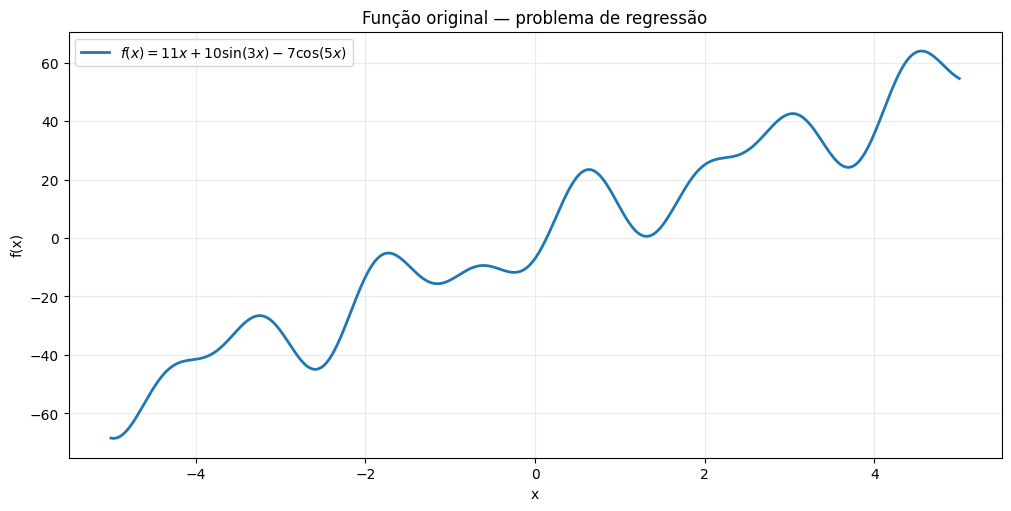

In [3]:
x_curva = np.linspace(X_MIN, X_MAX, 1000)
y_curva = funcao_alvo(x_curva)

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(x_curva, y_curva, color="tab:blue", linewidth=2,
        label=r"$f(x)=11x+10\sin(3x)-7\cos(5x)$")
ax.set(title="Função original — problema de regressão", xlabel="x", ylabel="f(x)")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 2. Geração e preparação dos dados

Foram geradas 3.000 amostras distribuídas uniformemente no intervalo \([-5,5]\). Essa quantidade foi escolhida para equilibrar o custo computacional dos experimentos, considerando que o problema possui uma única variável de entrada.

In [4]:
def gerar_dados(n_amostras=3000, x_min=-5, x_max=5, seed=42):
    if type(n_amostras) is not int or n_amostras < 10:
        raise ValueError("Use ao menos 10 amostras.")
    if not np.isfinite([x_min, x_max]).all() or x_min >= x_max:
        raise ValueError("O intervalo deve ser finito, com x_min < x_max.")
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_min, x_max, size=(n_amostras, 1))
    y = funcao_alvo(x)
    return x, y

N_AMOSTRAS = 3000
x_dados, y_dados = gerar_dados(N_AMOSTRAS, X_MIN, X_MAX, seed=SEED)
print(f"Geradas {len(x_dados)} amostras sem ruído, com seed {SEED}.")

Geradas 3000 amostras sem ruído, com seed 42.


### Divisão em treino, validação e teste

Vamos separar os dados aleatoriamente em **60% para treino, 20% para validação e 20% para teste**(não tem proporção obrigatória).
O conjunto de validação foi utilizado para selecionar hiperparâmetros e a melhor época de treinamento, enquanto o teste foi reservado para a avaliação final. A separação foi realizada aleatoriamente, com seed fixa, permitindo reproduzir os experimentos.

In [5]:
indices = np.arange(len(x_dados))
idx_treino, idx_restante = train_test_split(indices, test_size=0.4, random_state=SEED)
idx_validacao, idx_teste = train_test_split(idx_restante, test_size=0.5, random_state=SEED)
dados = {
    "Treino": {"x": x_dados[idx_treino], "y": y_dados[idx_treino]},
    "Validação": {"x": x_dados[idx_validacao], "y": y_dados[idx_validacao]},
    "Teste": {"x": x_dados[idx_teste], "y": y_dados[idx_teste]},
}
display(pd.DataFrame({nome: {
    "Amostras": len(d["x"]), "Proporção": len(d["x"]) / len(x_dados),
    "x mínimo": d["x"].min(), "x máximo": d["x"].max(),
} for nome, d in dados.items()}).T)

,Amostras,Proporção,x mínimo,x máximo
Treino,1800.0,0.6,-4.994319,4.994219
Validação,600.0,0.2,-4.989325,4.955553
Teste,600.0,0.2,-4.994813,4.997653


### Visualização dos dados

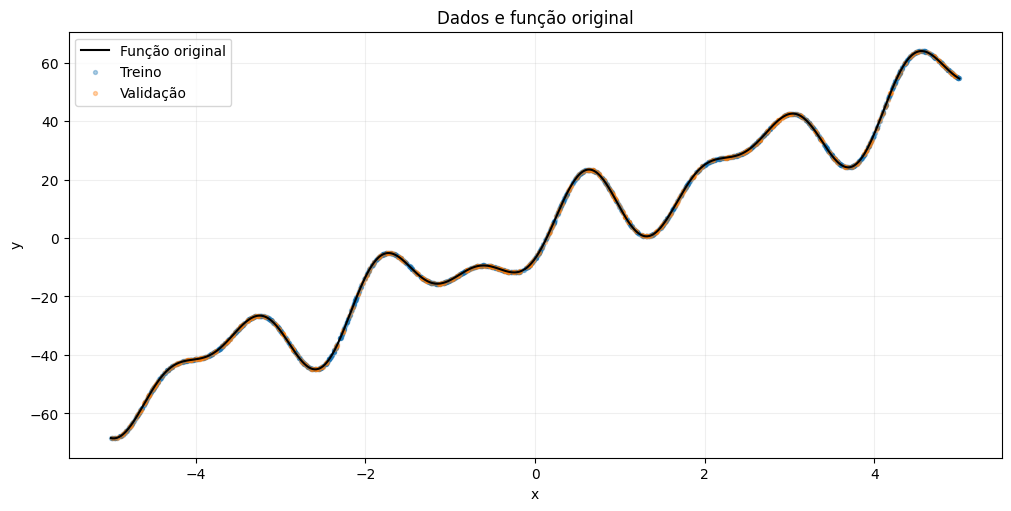

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(x_curva, y_curva, color="black", linewidth=1.5, label="Função original")
for nome in ("Treino", "Validação"):
    ax.scatter(dados[nome]["x"].ravel(), dados[nome]["y"].ravel(),
               s=8, alpha=0.35, label=nome)
ax.set(title="Dados e função original", xlabel="x", ylabel="y")
ax.legend()
ax.grid(alpha=0.2)
for extensao in ("png", "pdf"):
    fig.savefig(FIGURES_DIR / f"distribuicao_dados.{extensao}", dpi=200, bbox_inches="tight")
plt.show()

### Preparando os dados para utilizar no modelo

In [7]:
normalizacao = {
    "x_media": float(dados["Treino"]["x"].mean()),
    "x_desvio": float(dados["Treino"]["x"].std()),
    "y_media": float(dados["Treino"]["y"].mean()),
    "y_desvio": float(dados["Treino"]["y"].std()),
}
if min(normalizacao["x_desvio"], normalizacao["y_desvio"]) <= 0:
    raise ValueError("Os dados precisam ter variação em x e y.")

def preparar_tensores(x, y, normalizacao):
    x_pad = (x - normalizacao["x_media"]) / normalizacao["x_desvio"]
    y_pad = (y - normalizacao["y_media"]) / normalizacao["y_desvio"]
    return TensorDataset(torch.tensor(x_pad, dtype=torch.float32), torch.tensor(y_pad, dtype=torch.float32))

treino_ds = preparar_tensores(**dados["Treino"], normalizacao=normalizacao)
validacao_ds = preparar_tensores(**dados["Validação"], normalizacao=normalizacao)
teste_ds = preparar_tensores(**dados["Teste"], normalizacao=normalizacao)

pasta_dados = RESULTS_DIR / "dados"
pasta_dados.mkdir(parents=True, exist_ok=True)
np.savez(pasta_dados / "dados.npz", x=x_dados, y=y_dados,
         idx_treino=idx_treino, idx_validacao=idx_validacao, idx_teste=idx_teste)
(pasta_dados / "preparacao.json").write_text(json.dumps({
    "funcao": "11*x + 10*sin(3*x) - 7*cos(5*x)", 
    "seed": SEED,
    "dominio": [X_MIN, X_MAX], 
    "n_amostras": N_AMOSTRAS,
    "normalizacao": normalizacao,
}, indent=2, ensure_ascii=False), encoding="utf-8")

285

## 3. Geração do baseline (vanilla)

- Baseline com SGD e sendo uma MLP básica

- Configuração (hiperparâmetros) inicial

- Uso do optuna para encontrar e testar diferentes combinações de hiperparâmetros

- Selecionar melhor modelo baseline

### Modelo e funções de treinamento

A MLP recebe um valor de $x$ e prevê um valor de $y$, com saída linear. O baseline usa **SGD puro e perda MSE**. Treinamos na escala padronizada, mas calculamos **MAE, MSE, RMSE e R² na escala original**. Guardamos os pesos da época com menor MSE de validação.

In [8]:
def criar_modelo_baseline(config):
    #Verifica se a configuração do modelo está de acordo com o baseline esperado
    ativacoes = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}
    if config["optimizer"].lower() != "sgd":
        raise ValueError("O baseline deve usar SGD puro.")
    if any(config.get(k, 0) != 0 for k in ("l1", "l2", "dropout", "momentum")):
        raise ValueError("O baseline não utiliza regularização, dropout ou momentum.")
    if config["ativacao"] not in ativacoes:
        raise ValueError("Ativação deve ser relu, tanh ou sigmoid.")
    if not config["arquitetura"] or any(type(n) is not int or n <= 0 for n in config["arquitetura"]):
        raise ValueError("Use uma lista de quantidades positivas de neurônios.")
    for nome in ("epochs", "batch_size"):
        if type(config[nome]) is not int or config[nome] <= 0:
            raise ValueError(f"{nome} deve ser um inteiro positivo.")
    if not math.isfinite(config["learning_rate"]) or config["learning_rate"] <= 0:
        raise ValueError("Learning rate deve ser positivo e finito.")
    camadas, entradas = [], 1
    #Cria as camadas do modelo de acordo com a arquitetura definida na configuração
    for neuronios in config["arquitetura"]:
        camadas.extend([nn.Linear(entradas, neuronios), ativacoes[config["ativacao"]]()])
        entradas = neuronios
    #A saída do modelo é uma camada linear com um neurônio, pois estamos prevendo um valor real contínuo.
    camadas.append(nn.Linear(entradas, 1)) 
    return nn.Sequential(*camadas)

In [9]:
def avaliar_modelo(modelo, loader, normalizacao, device=None):
    if len(loader.dataset) < 2:
        raise ValueError("A avaliação precisa de ao menos duas amostras para calcular R².")
    #Prepara a rede para avaliação
    device = torch.device(device or next(modelo.parameters()).device)
    estava_treinando = modelo.training
    modelo.eval()
    previsoes, alvos = [], []

    #Faz as previsões
    try:
        with torch.no_grad():
            for x, y in loader:
                previsoes.append(modelo(x.to(device)).cpu())
                alvos.append(y.cpu())
    finally:
        modelo.train(estava_treinando)

    #Junta as previsões e alvos, converte para numpy e desnormaliza
    previsoes = torch.cat(previsoes).numpy().astype(np.float64).ravel()
    alvos = torch.cat(alvos).numpy().astype(np.float64).ravel()
    if not np.isfinite(previsoes).all():
        raise FloatingPointError("Previsões não finitas; revise o learning rate.")
    previsoes = previsoes * normalizacao["y_desvio"] + normalizacao["y_media"]
    alvos = alvos * normalizacao["y_desvio"] + normalizacao["y_media"]
    mse = float(mean_squared_error(alvos, previsoes))

    #Calcula métricas de avaliação do modelo e retorna
    return {"MAE": float(mean_absolute_error(alvos, previsoes)), "MSE": mse,"RMSE": math.sqrt(mse), "R²": float(r2_score(alvos, previsoes))}

In [10]:
def treinar_modelo(config, treino_ds, validacao_ds, normalizacao, seed=42, device=None, output_dir=None, verbose=True, ao_final_epoca=None):
    config = copy.deepcopy(config)
    escala = copy.deepcopy(normalizacao)
    if len(treino_ds) < 2 or len(validacao_ds) < 2:
        raise ValueError("Treino e validação precisam de ao menos duas amostras.")
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    torch.manual_seed(seed)

    #Cria o modelo, otimizador e critério de perda(MSE)
    modelo = criar_modelo_baseline(config).to(device)
    otimizador = torch.optim.SGD(modelo.parameters(), lr=config["learning_rate"], momentum=0.0, weight_decay=0.0)
    criterio = nn.MSELoss()

    #Cria os DataLoaders para treino e avaliação
    loader_treino = DataLoader(treino_ds, batch_size=config["batch_size"], shuffle=True, generator=torch.Generator().manual_seed(seed))
    loader_treino_avaliacao = DataLoader(treino_ds, batch_size=512, shuffle=False)
    loader_validacao = DataLoader(validacao_ds, batch_size=512, shuffle=False)

    pasta = Path(output_dir) if output_dir is not None else RESULTS_DIR / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    pasta.mkdir(parents=True, exist_ok=True)
    historico, melhor_mse, melhores_pesos, melhor_epoca = [], float("inf"), None, None
    inicio = perf_counter()
    if ao_final_epoca is not None:
        ao_final_epoca(0, modelo, None)
    if verbose:
        print(f"Dispositivo: {device} | Configuração: {config}", flush=True)

    #Ciclo de treino do modelo por épocas
    for epoca in range(1, config["epochs"] + 1):
        modelo.train()
        for x, y in loader_treino:
            x, y = x.to(device), y.to(device)
            otimizador.zero_grad(set_to_none=True)
            perda = criterio(modelo(x), y)
            if not torch.isfinite(perda).item():
                raise FloatingPointError("Perda não finita; revise o learning rate.")
            perda.backward()
            otimizador.step()

        #Avalia o modelo no conjunto de treino e validação, salvando métricas e pesos do melhor modelo
        treino = avaliar_modelo(modelo, loader_treino_avaliacao, escala, device)
        validacao = avaliar_modelo(modelo, loader_validacao, escala, device)
        historico.append({"epoch": epoca,
            **{f"train_{k}": v for k, v in treino.items()},
            **{f"val_{k}": v for k, v in validacao.items()}})

        #Guarda os pesos do modelo se a métrica de validação (MSE) for a melhor até o momento
        if validacao["MSE"] < melhor_mse:
            melhor_mse, melhor_epoca = validacao["MSE"], epoca
            melhores_pesos = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        if ao_final_epoca is not None:
            ao_final_epoca(epoca, modelo, validacao)
        if verbose and (epoca == 1 or epoca % 10 == 0 or epoca == config["epochs"]):
            print(f"Época {epoca:03d}/{config['epochs']} | MSE treino: {treino['MSE']:.4f} | "
                  f"MSE validação: {validacao['MSE']:.4f}", flush=True)
            
    duracao = perf_counter() - inicio
    modelo.load_state_dict(melhores_pesos)
    modelo.eval()

    resumo = {"config": config, 
              "seed": seed, 
              "device": str(device),
              "normalizacao": escala, 
              "train_size": len(treino_ds), 
              "val_size": len(validacao_ds),
              "melhor_epoca": melhor_epoca, 
              "duracao_segundos": duracao,
              "treino": avaliar_modelo(modelo, loader_treino_avaliacao, escala, device),
              "validacao": avaliar_modelo(modelo, loader_validacao, escala, device)}

    #Salva o modelo, histórico e resumo dos resultados em arquivos na pasta de saída
    torch.save({"model_state_dict": melhores_pesos, 
                "config": config, 
                "seed": seed,
                "normalizacao": escala, 
                "epoch": melhor_epoca, 
                "val_mse": melhor_mse},
               pasta / "melhor_modelo.pt")
    
    historico = pd.DataFrame(historico)
    historico.to_csv(pasta / "historico.csv", index=False)
    (pasta / "resultado.json").write_text(json.dumps(resumo, indent=2, ensure_ascii=False), encoding="utf-8")
    if verbose:
        print(f"Melhor época: {melhor_epoca} | MSE validação: {melhor_mse:.4f} | Tempo: {duracao:.1f}s")
        print(f"Resultados: {pasta}")
    return {"modelo": modelo, "historico": historico, "resumo": resumo, "output_dir": pasta}

In [11]:
#Função para fazer previsões com o modelo treinado, desnormalizando os resultados
def prever(modelo, x, normalizacao):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    x_pad = (x - normalizacao["x_media"]) / normalizacao["x_desvio"]
    device = next(modelo.parameters()).device
    estava_treinando = modelo.training
    modelo.eval()
    try:
        with torch.no_grad():
            pred = modelo(torch.tensor(x_pad, dtype=torch.float32, device=device)).cpu().numpy()
    finally:
        modelo.train(estava_treinando)
    return pred.ravel() * normalizacao["y_desvio"] + normalizacao["y_media"]

def plotar_resultados(resultado, x_curva, y_curva, x_validacao, y_validacao):
    hist = resultado["historico"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    for ax, metrica in zip(axes.ravel(), ("MAE", "MSE", "RMSE", "R²")):
        ax.plot(hist["epoch"], hist[f"train_{metrica}"], label="Treino")
        ax.plot(hist["epoch"], hist[f"val_{metrica}"], label="Validação")
        ax.axvline(resultado["resumo"]["melhor_epoca"], color="gray", linestyle="--", label="Melhor época")
        ax.set(title=metrica, xlabel="Época", ylabel=metrica)
        ax.grid(alpha=0.2)
        ax.legend()
    for ext in ("png", "pdf"):
        fig.savefig(resultado["output_dir"] / f"curvas_treinamento.{ext}", dpi=200, bbox_inches="tight")
    plt.show()
    escala = resultado["resumo"]["normalizacao"]
    pred = prever(resultado["modelo"], x_curva, escala)
    pred_val = prever(resultado["modelo"], x_validacao, escala)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
    axes[0].plot(x_curva, y_curva, color="black", label="Função original")
    axes[0].plot(x_curva, pred, label="Previsão da MLP")
    axes[0].set(title="Aproximação da função", xlabel="x", ylabel="y")
    axes[0].legend()
    axes[1].scatter(np.asarray(x_validacao).ravel(), np.asarray(y_validacao).ravel() - pred_val, s=10, alpha=0.5)
    axes[1].axhline(0, color="black", linestyle="--")
    axes[1].set(title="Resíduos na validação", xlabel="x", ylabel="y real − y previsto")
    for ax in axes:
        ax.grid(alpha=0.2)
    for ext in ("png", "pdf"):
        fig.savefig(resultado["output_dir"] / f"aproximacao_funcao.{ext}", dpi=200, bbox_inches="tight")
    plt.show()

### Configuração inicial

In [12]:
config_inicial = {
    "arquitetura": [128, 64],
    "ativacao": "relu",
    "learning_rate": 0.01,
    "batch_size": 64,
    "epochs": 500,
    "optimizer": "sgd",
}
resultado_inicial = treinar_modelo(
    config_inicial, treino_ds, validacao_ds, normalizacao, seed=SEED, device=DEVICE,
)

Dispositivo: cuda | Configuração: {'arquitetura': [128, 64], 'ativacao': 'relu', 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 500, 'optimizer': 'sgd'}
Época 001/500 | MSE treino: 85.6244 | MSE validação: 81.6026
Época 010/500 | MSE treino: 79.1449 | MSE validação: 76.3954
Época 020/500 | MSE treino: 74.6738 | MSE validação: 70.9564
Época 030/500 | MSE treino: 72.5964 | MSE validação: 69.1774
Época 040/500 | MSE treino: 71.6939 | MSE validação: 68.8011
Época 050/500 | MSE treino: 70.2533 | MSE validação: 67.2042
Época 060/500 | MSE treino: 69.3961 | MSE validação: 66.6459
Época 070/500 | MSE treino: 68.7266 | MSE validação: 66.1414
Época 080/500 | MSE treino: 67.8970 | MSE validação: 64.9972
Época 090/500 | MSE treino: 67.4915 | MSE validação: 64.7833
Época 100/500 | MSE treino: 66.8706 | MSE validação: 64.6083
Época 110/500 | MSE treino: 65.3721 | MSE validação: 63.0411
Época 120/500 | MSE treino: 64.7697 | MSE validação: 62.5394
Época 130/500 | MSE treino: 64.6542 | MSE validaçã

,MAE,MSE,RMSE,R²
Treino,3.9934,22.8699,4.7822,0.9803
Validação,3.7009,19.9632,4.4680,0.9823


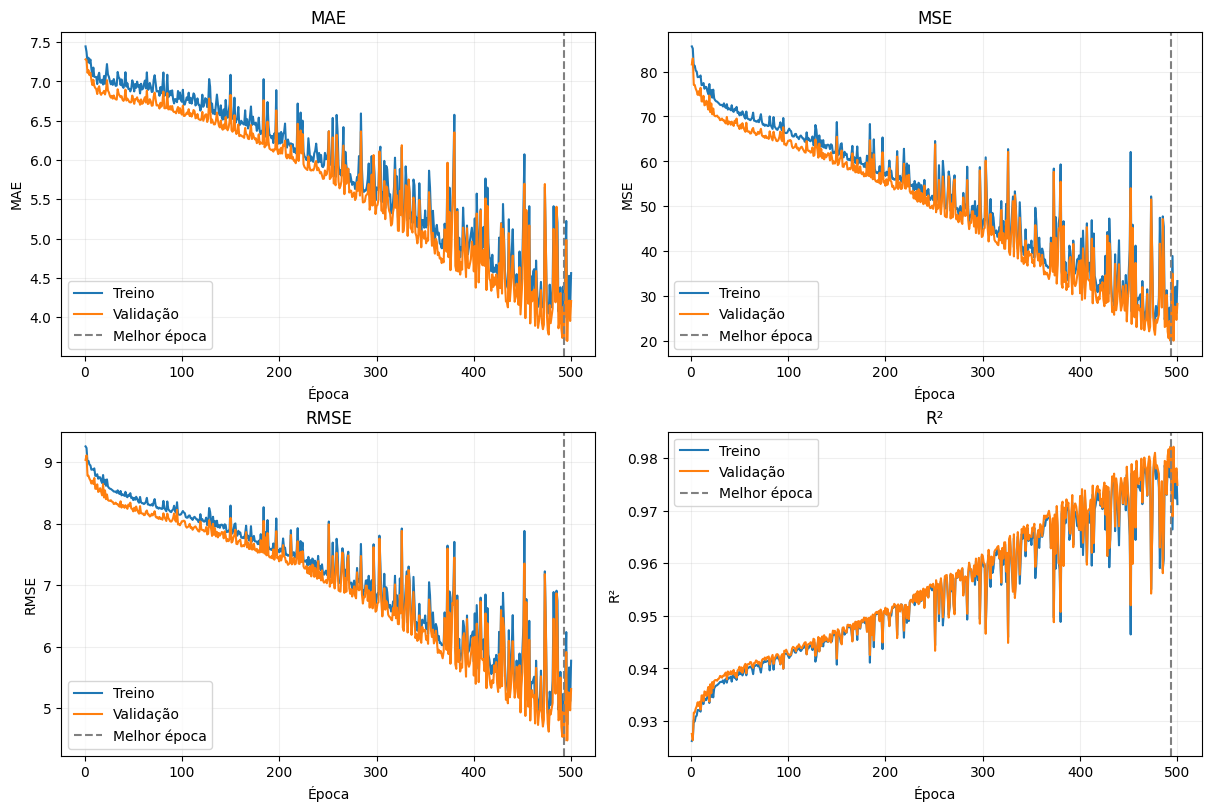

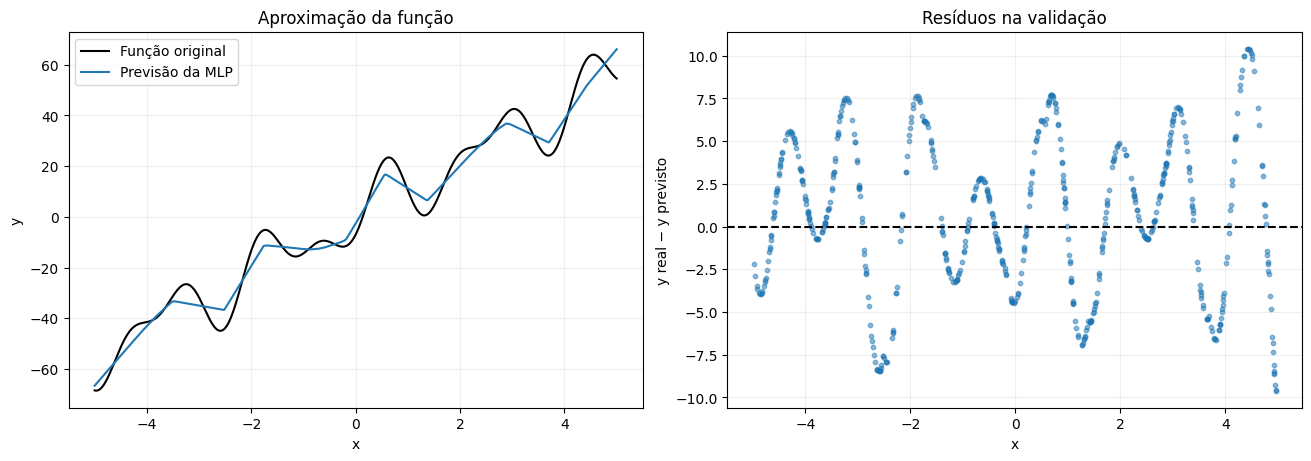

In [13]:
display(pd.DataFrame({"Treino": resultado_inicial["resumo"]["treino"],
                      "Validação": resultado_inicial["resumo"]["validacao"]}).T.style.format("{:.4f}"))
plotar_resultados(resultado_inicial, x_curva, y_curva, dados["Validação"]["x"], dados["Validação"]["y"])

### Busca de hiperparâmetros com Optuna

O Optuna sugere configurações e usa o **menor MSE de validação** para orientar a busca. O otimizador dos pesos continua sendo SGD puro.

Testaremos 1 a 3 camadas, 32/64/128 neurônios, ReLU/Tanh/Sigmoid, learning rate de 0,001 a 0,1 e batch size de 32/64/128. Começamos com **20 tentativas**, usando o mesmo orçamento de épocas da configuração inicial.

In [14]:
#Função para sugerir uma configuração de modelo usando Optuna
def sugerir_config(trial, config_base, epochs):
    config = copy.deepcopy(config_base)
    n_camadas = trial.suggest_int("n_camadas", 1, 3)
    config["arquitetura"] = [trial.suggest_categorical(f"neuronios_{i}", [32, 64, 128]) for i in range(n_camadas)]
    config["ativacao"] = trial.suggest_categorical("ativacao", ["relu", "tanh", "sigmoid"])
    config["learning_rate"] = trial.suggest_float("learning_rate", 0.001, 0.1, log=True)
    config["batch_size"] = trial.suggest_categorical("batch_size", [32, 64, 128])
    config.update(epochs=epochs, optimizer="sgd")
    return config

In [15]:
def buscar_hiperparametros(config_base, treino_ds, validacao_ds, normalizacao, n_trials=20, epochs=500, seed=42, device=None, resultado_base=None):

    if type(n_trials) is not int or n_trials <= 0 or type(epochs) is not int or epochs <= 0:
        raise ValueError("n_trials e epochs devem ser inteiros positivos.")
    
    pasta = RESULTS_DIR / ("optuna_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
    pasta.mkdir(parents=True, exist_ok=True)
    config_comparacao = copy.deepcopy(config_base)
    config_comparacao["epochs"] = epochs

    #Verifica se a configuração inicial pode ser reutilizada, comparando com a configuração base, seed e normalização
    reutilizar = (resultado_base is not None
                  and resultado_base["resumo"]["config"] == config_comparacao
                  and resultado_base["resumo"]["seed"] == seed
                  and resultado_base["resumo"]["normalizacao"] == normalizacao)
    
    if not reutilizar:
        resultado_base = treinar_modelo(config_comparacao, treino_ds, validacao_ds, normalizacao, seed=seed, device=device, output_dir=pasta / "modelo_inicial", verbose=False)

    #Função objetivo para o estudo do Optuna, que treina o modelo com a configuração sugerida e retorna o MSE de validação
    def objetivo(trial):
        config = sugerir_config(trial, config_base, epochs)
        resultado = treinar_modelo(config, treino_ds, validacao_ds, normalizacao, seed=seed, device=device, output_dir=pasta / f"trial_{trial.number:03d}", verbose=False)
        resumo = resultado["resumo"]
        trial.set_user_attr("config", config)
        trial.set_user_attr("output_dir", str(resultado["output_dir"]))
        trial.set_user_attr("melhor_epoca", resumo["melhor_epoca"])
        trial.set_user_attr("duracao_segundos", resumo["duracao_segundos"])
        return resumo["validacao"]["MSE"]

    #Função de callback para registrar os resultados de cada tentativa do estudo do Optuna
    def registrar(estudo, trial):
        estudo.trials_dataframe().to_csv(pasta / "tentativas.csv", index=False)
        if trial.state == optuna.trial.TrialState.COMPLETE:
            print(f"Tentativa {trial.number + 1}/{n_trials} | Melhor época: {trial.user_attrs['melhor_epoca']} | "
                  f"MSE validação: {trial.value:.4f} | Config: {trial.user_attrs['config']}", flush=True)
        else:
            print(f"Tentativa {trial.number + 1}/{n_trials}: falhou por instabilidade numérica.", flush=True)

    #Configura o estudo do Optuna
    nivel_logs = optuna.logging.get_verbosity()
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    try:
        estudo = optuna.create_study(direction="minimize", study_name="baseline_regressao",
            sampler=optuna.samplers.TPESampler(seed=seed), pruner=optuna.pruners.NopPruner(),
            storage="sqlite:///" + (pasta / "estudo.db").as_posix())
        arquitetura = config_base["arquitetura"]
        if (1 <= len(arquitetura) <= 3 and all(n in [32, 64, 128] for n in arquitetura)
            and config_base["ativacao"] in ["relu", "tanh", "sigmoid"]
            and config_base["batch_size"] in [32, 64, 128]
            and 0.001 <= config_base["learning_rate"] <= 0.1):
            estudo.enqueue_trial({"n_camadas": len(arquitetura), "ativacao": config_base["ativacao"],
                "batch_size": config_base["batch_size"], "learning_rate": config_base["learning_rate"],
                **{f"neuronios_{i}": n for i, n in enumerate(arquitetura)}})
        estudo.optimize(objetivo, n_trials=n_trials, callbacks=[registrar], n_jobs=1,
                        gc_after_trial=True, catch=(FloatingPointError,))
        
    finally:
        optuna.logging.set_verbosity(nivel_logs)
    concluidas = [t for t in estudo.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if not concluidas:
        raise RuntimeError("Nenhuma tentativa concluiu; revise os hiperparâmetros.")

    #Seleciona a melhor tentativa do estudo, comparando com a configuração inicial, e copia os arquivos relevantes para a pasta de resultados
    melhor = estudo.best_trial
    origem = Path(melhor.user_attrs["output_dir"])
    fonte = f"Tentativa {melhor.number + 1}"
    if resultado_base["resumo"]["validacao"]["MSE"] < melhor.value:
        origem = Path(resultado_base["output_dir"])
        fonte = "Configuração inicial"
    pasta_best = RESULTS_DIR / "optuna_best"
    pasta_best.mkdir(parents=True, exist_ok=True)
    for arquivo in ("melhor_modelo.pt", "resultado.json", "historico.csv"):
        copy2(origem / arquivo, pasta_best / arquivo)
    resumo = json.loads((pasta_best / "resultado.json").read_text(encoding="utf-8"))
    (pasta_best / "melhor_config.json").write_text(json.dumps(resumo["config"], indent=2), encoding="utf-8")
    (pasta_best / "origem.json").write_text(json.dumps({"estudo": str(pasta), "origem": str(origem),
        "selecionado": fonte}, indent=2, ensure_ascii=False), encoding="utf-8")
    return {"estudo": estudo, "output_dir": pasta, "melhor_config": resumo["config"],
            "melhor_modelo_path": pasta_best / "melhor_modelo.pt", "origem_vencedor": fonte,
            "resultado_inicial": resultado_base}

In [16]:
N_TRIALS = 20
EPOCHS_OPTUNA = config_inicial["epochs"]
busca_optuna = buscar_hiperparametros(config_inicial, treino_ds, validacao_ds, normalizacao,n_trials=N_TRIALS, epochs=EPOCHS_OPTUNA, seed=SEED, device=DEVICE,resultado_base=resultado_inicial,)
optuna_best = {
    "config": copy.deepcopy(busca_optuna["melhor_config"]),
    "checkpoint": busca_optuna["melhor_modelo_path"],
}
print(f"Melhor modelo salvo em: {optuna_best['checkpoint']}")

Tentativa 1/20 | Melhor época: 493 | MSE validação: 19.9632 | Config: {'arquitetura': [128, 64], 'ativacao': 'relu', 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 500, 'optimizer': 'sgd'}
Tentativa 2/20 | Melhor época: 500 | MSE validação: 64.9669 | Config: {'arquitetura': [32, 32], 'ativacao': 'relu', 'learning_rate': 0.0010994335574766201, 'batch_size': 32, 'epochs': 500, 'optimizer': 'sgd'}
Tentativa 3/20 | Melhor época: 491 | MSE validação: 74.3566 | Config: {'arquitetura': [128], 'ativacao': 'sigmoid', 'learning_rate': 0.0019010245319870357, 'batch_size': 128, 'epochs': 500, 'optimizer': 'sgd'}
Tentativa 4/20 | Melhor época: 470 | MSE validação: 20.5081 | Config: {'arquitetura': [128, 64, 128], 'ativacao': 'relu', 'learning_rate': 0.0233596350262616, 'batch_size': 128, 'epochs': 500, 'optimizer': 'sgd'}
Tentativa 5/20 | Melhor época: 500 | MSE validação: 75.6741 | Config: {'arquitetura': [32], 'ativacao': 'sigmoid', 'learning_rate': 0.0023426581058204046, 'batch_size': 32, 'e

,number,value,datetime_start,datetime_complete,duration,params_ativacao,params_batch_size,params_learning_rate,params_n_camadas,params_neuronios_0,params_neuronios_1,params_neuronios_2,user_attrs_config,user_attrs_duracao_segundos,user_attrs_melhor_epoca,user_attrs_output_dir,system_attrs_fixed_params,state
18,18,1.691247,2026-09-17 17:33:29.505109,2026-09-17 17:34:00.281385,0 days 00:00:30.776276,relu,64,0.053193,3,64,32.0,32.0,"{'arquitetura': [64, 32, 32], 'ativacao': 'rel...",30.701263,498,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
19,19,1.794277,2026-09-17 17:34:00.474246,2026-09-17 17:34:31.150680,0 days 00:00:30.676434,relu,64,0.047525,3,64,32.0,32.0,"{'arquitetura': [64, 32, 32], 'ativacao': 'rel...",30.598669,492,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
15,15,5.029290,2026-09-17 17:32:06.428885,2026-09-17 17:32:34.816131,0 days 00:00:28.387246,relu,64,0.055799,2,64,32.0,NaN,"{'arquitetura': [64, 32], 'ativacao': 'relu', ...",28.313390,479,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
17,17,5.091226,2026-09-17 17:33:00.768575,2026-09-17 17:33:29.310563,0 days 00:00:28.541988,relu,64,0.049596,2,64,32.0,NaN,"{'arquitetura': [64, 32], 'ativacao': 'relu', ...",28.466987,482,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
11,11,10.874887,2026-09-17 17:30:12.451968,2026-09-17 17:30:40.831665,0 days 00:00:28.379697,relu,64,0.019383,2,128,64.0,NaN,"{'arquitetura': [128, 64], 'ativacao': 'relu',...",28.306820,487,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
14,14,13.979039,2026-09-17 17:31:38.038375,2026-09-17 17:32:06.235222,0 days 00:00:28.196847,relu,64,0.012774,2,128,64.0,NaN,"{'arquitetura': [128, 64], 'ativacao': 'relu',...",28.122499,487,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
12,12,14.837669,2026-09-17 17:30:41.021660,2026-09-17 17:31:09.509842,0 days 00:00:28.488182,relu,64,0.012134,2,128,64.0,NaN,"{'arquitetura': [128, 64], 'ativacao': 'relu',...",28.413610,496,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
0,0,19.963177,2026-09-17 17:24:08.048119,2026-09-17 17:24:39.487208,0 days 00:00:31.439089,relu,64,0.010000,2,128,64.0,NaN,"{'arquitetura': [128, 64], 'ativacao': 'relu',...",31.341366,493,C:\Users\davis\Documents\vscode\redesNeuraisUC...,"{'n_camadas': 2, 'ativacao': 'relu', 'batch_si...",COMPLETE
3,3,20.508075,2026-09-17 17:25:49.156058,2026-09-17 17:26:11.934471,0 days 00:00:22.778413,relu,128,0.023360,3,128,64.0,128.0,"{'arquitetura': [128, 64, 128], 'ativacao': 'r...",22.700305,470,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE
7,7,57.083728,2026-09-17 17:27:39.653972,2026-09-17 17:28:09.831882,0 days 00:00:30.177910,relu,64,0.007163,2,32,64.0,NaN,"{'arquitetura': [32, 64], 'ativacao': 'relu', ...",30.105853,496,C:\Users\davis\Documents\vscode\redesNeuraisUC...,NaN,COMPLETE


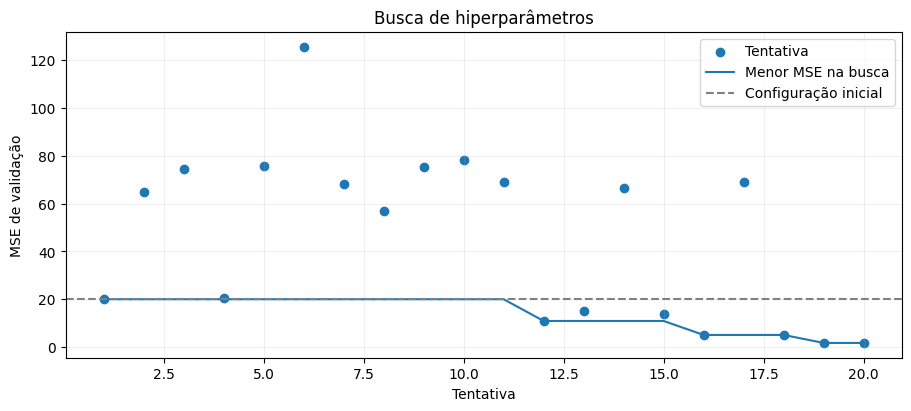

In [17]:
tentativas = busca_optuna["estudo"].trials_dataframe()
display(tentativas.sort_values("value").head(10))
concluidas = tentativas[tentativas["state"] == "COMPLETE"].copy()
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.scatter(concluidas["number"] + 1, concluidas["value"], label="Tentativa")
ax.plot(concluidas["number"] + 1, concluidas["value"].cummin(), label="Menor MSE na busca")
ax.axhline(busca_optuna["resultado_inicial"]["resumo"]["validacao"]["MSE"],
           linestyle="--", color="gray", label="Configuração inicial")
ax.set(title="Busca de hiperparâmetros", xlabel="Tentativa", ylabel="MSE de validação")
ax.legend()
ax.grid(alpha=0.2)
for ext in ("png", "pdf"):
    fig.savefig(busca_optuna["output_dir"] / f"historico_optuna.{ext}", dpi=200, bbox_inches="tight")
plt.show()

### Melhor baseline e comparação na validação

Carregamos os melhores pesos sem treinar novamente. Comparamos a configuração inicial e o baseline final pelo mesmo conjunto de validação e pelo mesmo orçamento de épocas. Menores MAE, MSE e RMSE são melhores; para R², o ideal é 1.

,MAE,MSE,RMSE,R²
Modelo,,,,
Configuração inicial,3.7009,19.9632,4.4680,0.9823
Baseline final,1.0244,1.6912,1.3005,0.9985


Selecionado: Tentativa 19
Configuração: {'arquitetura': [64, 32, 32], 'ativacao': 'relu', 'learning_rate': 0.05319301949684397, 'batch_size': 64, 'epochs': 500, 'optimizer': 'sgd'}
Melhor época: 498
Redução absoluta do MSE de validação: 18.2719
Vários hiperparâmetros mudaram juntos; não podemos atribuir a diferença somente ao número de camadas.


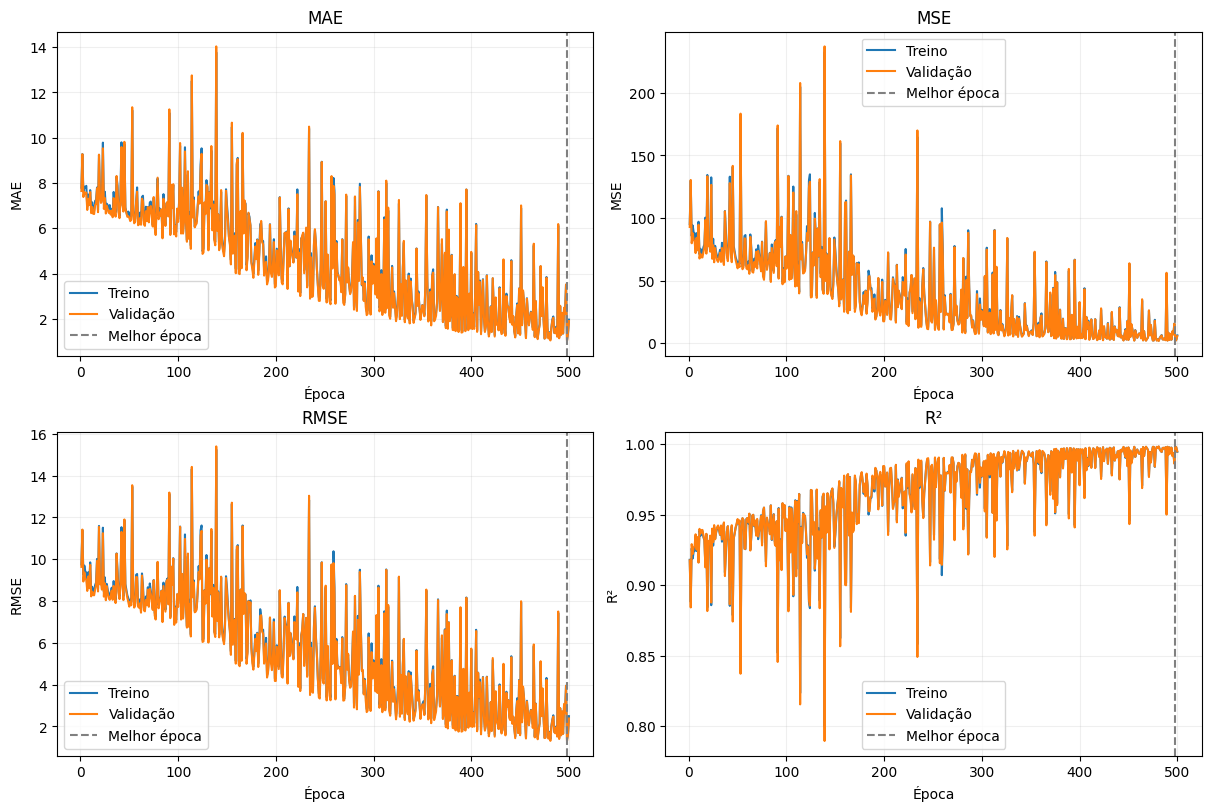

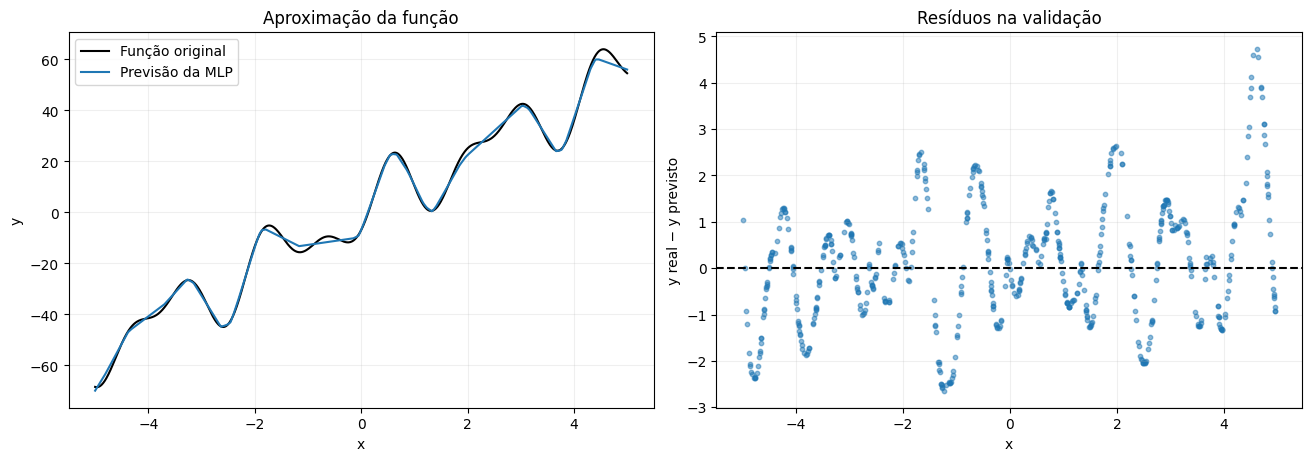

In [18]:
checkpoint = torch.load(optuna_best["checkpoint"], map_location="cpu", weights_only=True)
modelo_baseline = criar_modelo_baseline(checkpoint["config"]).to(DEVICE)
modelo_baseline.load_state_dict(checkpoint["model_state_dict"])
modelo_baseline.eval()
pasta_best = optuna_best["checkpoint"].parent
resultado_baseline = {
    "modelo": modelo_baseline,
    "resumo": json.loads((pasta_best / "resultado.json").read_text(encoding="utf-8")),
    "historico": pd.read_csv(pasta_best / "historico.csv"),
    "output_dir": pasta_best,
}
tabela_baseline = pd.DataFrame({
    "Configuração inicial": busca_optuna["resultado_inicial"]["resumo"]["validacao"],
    "Baseline final": resultado_baseline["resumo"]["validacao"],
}).T
tabela_baseline.index.name = "Modelo"
display(tabela_baseline.style.format("{:.4f}"))
tabela_baseline.to_csv(busca_optuna["output_dir"] / "comparacao_validacao.csv")
print(f"Selecionado: {busca_optuna['origem_vencedor']}")
print(f"Configuração: {optuna_best['config']}")
print(f"Melhor época: {resultado_baseline['resumo']['melhor_epoca']}")
reducao = tabela_baseline.loc["Configuração inicial", "MSE"] - tabela_baseline.loc["Baseline final", "MSE"]
print(f"Redução absoluta do MSE de validação: {reducao:.4f}")
if resultado_baseline["resumo"]["melhor_epoca"] == optuna_best["config"]["epochs"]:
    print("A melhor época foi a última; vale investigar um orçamento maior na validação.")
print("Vários hiperparâmetros mudaram juntos; não podemos atribuir a diferença somente ao número de camadas.")
plotar_resultados(resultado_baseline, x_curva, y_curva, dados["Validação"]["x"], dados["Validação"]["y"])

### Evolução da aproximação ao longo das épocas

Repetimos o treinamento da configuração vencedora, desde a inicialização, com a mesma seed e os mesmos dados. Registramos as previsões em uma grade fixa de valores de $x$. Isso é necessário porque a busca anterior salvou apenas os melhores pesos, não todos os estados intermediários.

In [19]:
def registrar_evolucao(config, treino_ds, validacao_ds, normalizacao, x_curva,
                       seed=42, device=None, output_dir=None, funcao_treino=None):
    pasta = Path(output_dir) if output_dir is not None else RESULTS_DIR / (
        "evolucao_baseline_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    x_grade = np.sort(np.asarray(x_curva, dtype=float).ravel())
    registros = []

    def capturar(epoca, modelo, validacao):
        registros.append({
            "epoca": epoca,
            "previsoes": prever(modelo, x_grade, normalizacao).copy(),
            "mse_validacao": np.nan if validacao is None else validacao["MSE"],
        })
        if epoca % 50 == 0 or epoca == config["epochs"]:
            print(f"Registrando evolução: época {epoca}/{config['epochs']}", flush=True)

    treinar = treinar_modelo if funcao_treino is None else funcao_treino
    resultado = treinar(
        config, treino_ds, validacao_ds, normalizacao, seed=seed, device=device,
        output_dir=pasta, verbose=False, ao_final_epoca=capturar,
    )
    evolucao = {
        "x": x_grade,
        "epocas": np.array([r["epoca"] for r in registros]),
        "previsoes": np.stack([r["previsoes"] for r in registros]),
        "mse_validacao": np.array([r["mse_validacao"] for r in registros]),
    }
    np.savez_compressed(pasta / "previsoes_por_epoca.npz", **evolucao)
    return {"resultado": resultado, "evolucao": evolucao, "output_dir": pasta}


def visualizar_evolucao(registro, intervalo_fotos=50, intervalo_gif=5, fps=8, nome_gif="evolucao_baseline.gif", mostrar_gif=False):
    from matplotlib.animation import FuncAnimation, PillowWriter
    from IPython.display import Image

    if any(type(v) is not int or v <= 0 for v in (intervalo_fotos, intervalo_gif, fps)):
        raise ValueError("Os intervalos e fps devem ser inteiros positivos.")
    pasta = Path(registro["output_dir"])
    fotos_dir = pasta / "fotos"
    fotos_dir.mkdir(parents=True, exist_ok=True)
    e = registro["evolucao"]
    x, pred, epocas = e["x"], e["previsoes"], e["epocas"]
    y = funcao_alvo(x)
    melhor_epoca = registro["resultado"]["resumo"]["melhor_epoca"]
    limites = (min(float(y.min()), float(pred.min())), max(float(y.max()), float(pred.max())))
    margem = max((limites[1] - limites[0]) * 0.06, 1.0)
    ylim = (limites[0] - margem, limites[1] + margem)

    def titulo(i):
        texto = f"Época {epocas[i]}"
        if epocas[i] == 0:
            return texto + " — antes do treino"
        texto += f" | MSE val.: {e['mse_validacao'][i]:.3f}"
        if epocas[i] == melhor_epoca:
            texto += " | melhor época"
        return texto

    def desenhar(ax, i):
        ax.plot(x, y, color="black", linewidth=1.8, label="Função original")
        ax.plot(x, pred[i], color="tab:blue", linewidth=1.8, label="Previsão da MLP")
        ax.set(xlim=(x.min(), x.max()), ylim=ylim, xlabel="x", ylabel="y", title=titulo(i))
        ax.grid(alpha=0.2)

    selecionadas = sorted(set([0, int(epocas[-1]), melhor_epoca] +
                              list(range(intervalo_fotos, int(epocas[-1]) + 1, intervalo_fotos))))
    indices = [int(np.flatnonzero(epocas == epoca)[0]) for epoca in selecionadas]
    for i in indices:
        fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
        desenhar(ax, i)
        ax.legend(loc="upper left")
        fig.savefig(fotos_dir / f"epoca_{epocas[i]:04d}.png", dpi=200)
        if epocas[i] == melhor_epoca:
            for ext in ("png", "pdf"):
                fig.savefig(pasta / f"melhor_epoca.{ext}", dpi=250)
        plt.close(fig)

    linhas = math.ceil(len(indices) / 3)
    fig, axes = plt.subplots(linhas, 3, figsize=(16, 3.6 * linhas), squeeze=False,
                             layout="constrained")
    for ax, i in zip(axes.ravel(), indices):
        desenhar(ax, i)
    for ax in axes.ravel()[len(indices):]:
        ax.set_visible(False)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Evolução da configuração vencedora — aproximação da função", fontsize=15)
    for ext in ("png", "pdf"):
        fig.savefig(pasta / f"painel_evolucao.{ext}", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    frames = sorted(set(range(0, len(epocas), intervalo_gif)) |
                    {len(epocas) - 1, int(np.flatnonzero(epocas == melhor_epoca)[0])})
    fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
    ax.plot(x, y, color="black", linewidth=2, label="Função original")
    linha, = ax.plot(x, pred[0], color="tab:blue", linewidth=2, label="Previsão da MLP")
    ax.set(xlim=(x.min(), x.max()), ylim=ylim, xlabel="x", ylabel="y")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left")

    def atualizar(i):
        linha.set_ydata(pred[i])
        ax.set_title(titulo(i))
        return linha,

    animacao = FuncAnimation(fig, atualizar, frames=frames, interval=1000 / fps, blit=False)
    gif_path = pasta / nome_gif
    animacao.save(gif_path, writer=PillowWriter(fps=fps), dpi=100)
    plt.close(fig)
    if mostrar_gif:
        display(Image(filename=str(gif_path)))
    print(f"GIF, imagens individuais e painel salvos em: {pasta}")
    return gif_path


In [20]:
# Usa o checkpoint selecionado pela validação, sem executar o Optuna novamente.
checkpoint_evolucao = torch.load(optuna_best["checkpoint"], map_location="cpu", weights_only=True)
registro_evolucao = registrar_evolucao(
    checkpoint_evolucao["config"], treino_ds, validacao_ds,
    checkpoint_evolucao["normalizacao"], x_curva,
    seed=checkpoint_evolucao["seed"], device=DEVICE,
)
(registro_evolucao["output_dir"] / "origem.json").write_text(json.dumps({
    "checkpoint_optuna": str(optuna_best["checkpoint"]),
    "melhor_epoca_original": checkpoint_evolucao["epoch"],
    "mse_validacao_original": checkpoint_evolucao["val_mse"],
    "mse_validacao_reexecucao": registro_evolucao["resultado"]["resumo"]["validacao"]["MSE"],
}, indent=2), encoding="utf-8")


Registrando evolução: época 0/500
Registrando evolução: época 50/500
Registrando evolução: época 100/500
Registrando evolução: época 150/500
Registrando evolução: época 200/500
Registrando evolução: época 250/500
Registrando evolução: época 300/500
Registrando evolução: época 350/500
Registrando evolução: época 400/500
Registrando evolução: época 450/500
Registrando evolução: época 500/500


270

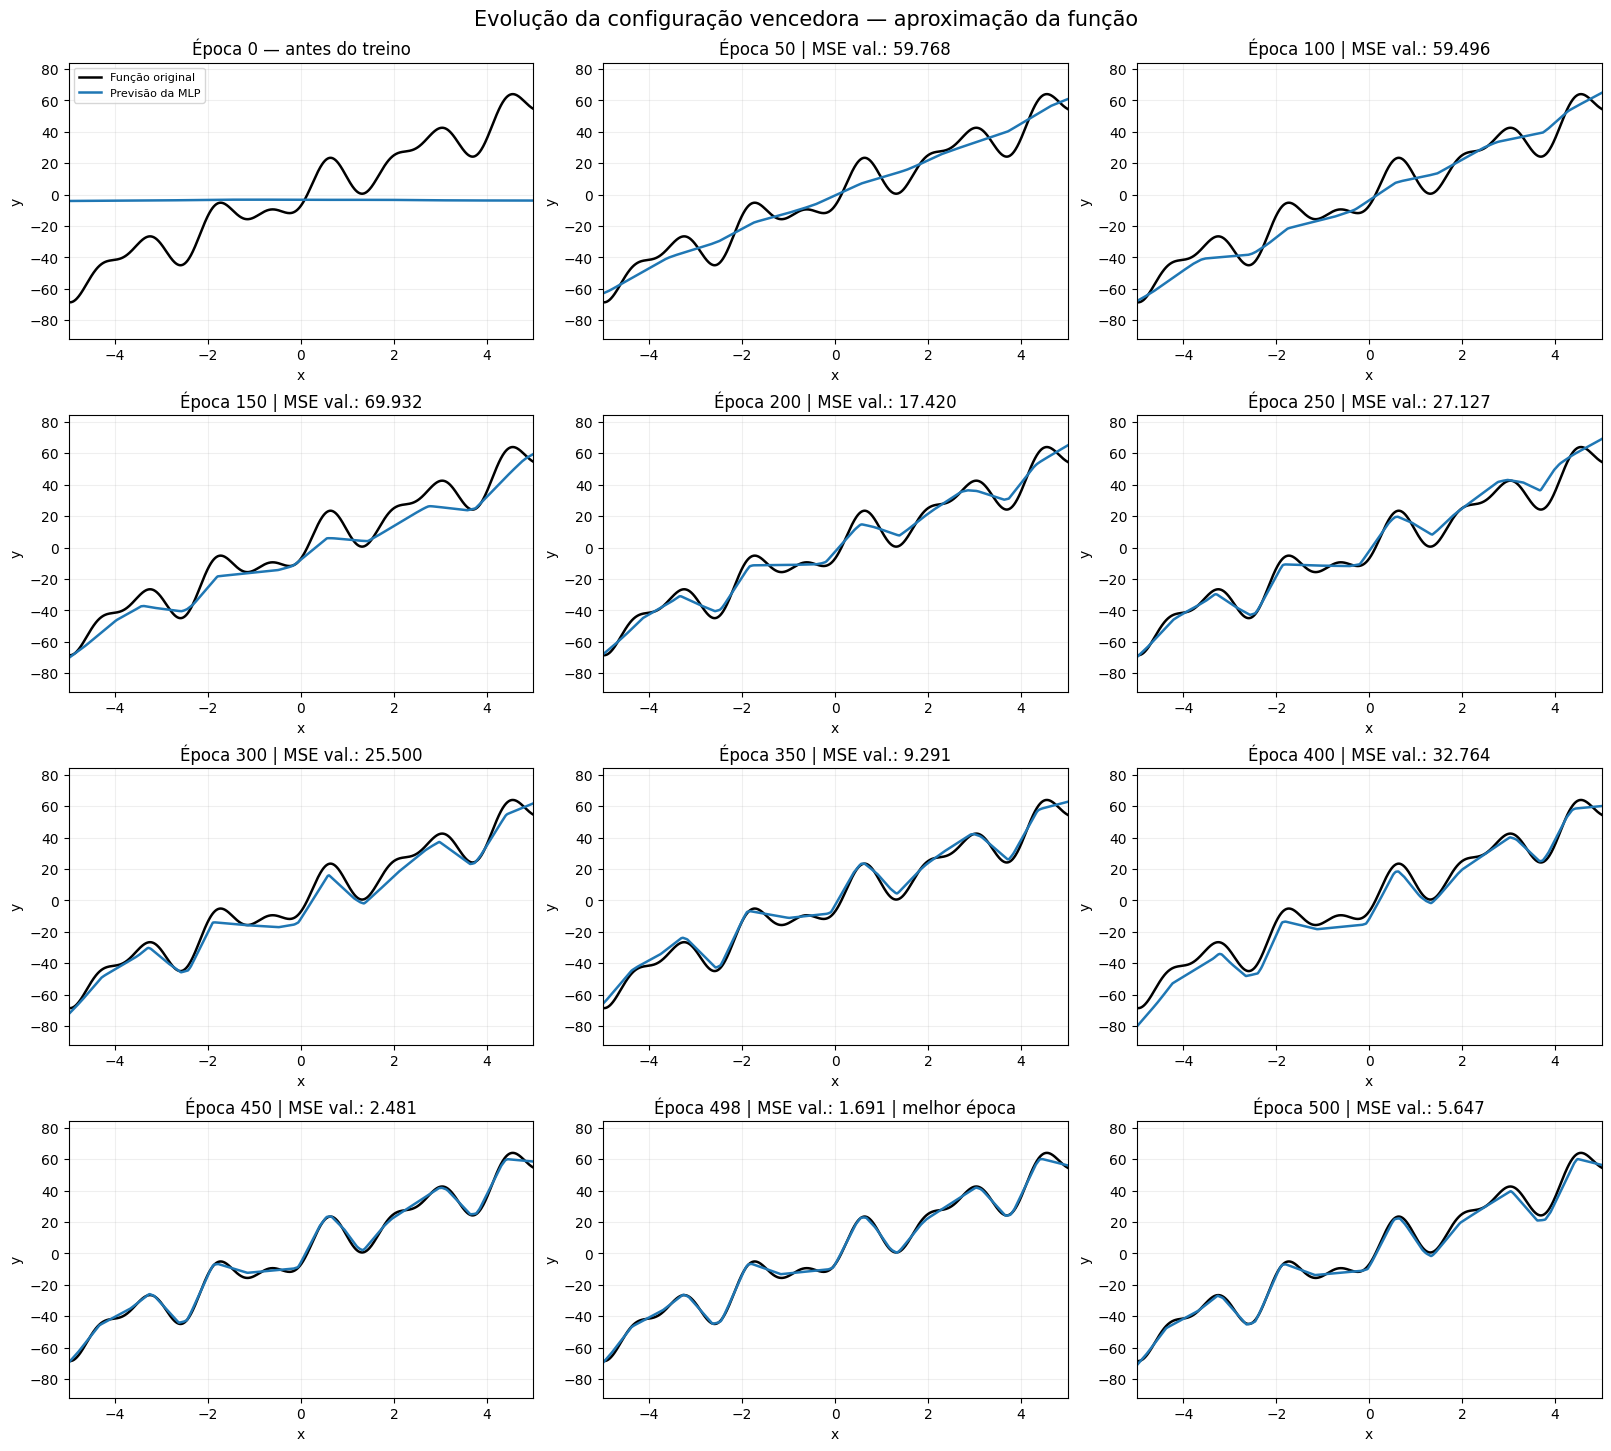

GIF, imagens individuais e painel salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\regression\evolucao_baseline_20260917_173433_601562


In [21]:
# Mostra apenas o painel estático; o GIF é salvo para abrir depois.
caminho_gif = visualizar_evolucao(registro_evolucao, intervalo_fotos=50, intervalo_gif=5, fps=8)

## 4. Estudo de ablação

Comparamos cinco casos: **baseline**, **baseline + L1**, **baseline + L2**, **baseline + dropout** e **baseline + momentum**.

Todos começam do zero usando a configuração vencedora do Optuna, com **500 épocas**, a mesma seed, os mesmos pesos iniciais das camadas lineares e a mesma divisão dos dados. A arquitetura e os hiperparâmetros base permanecem fixos; adicionamos uma técnica por vez.

Valores iniciais: **L1 = 0,000001**, **L2 = 0,0001**, **dropout = 0,20** e **momentum = 0,90**. Eles são configuráveis e ainda não foram otimizados para a regressão.

In [22]:
def criar_modelo_ablacao(config):

    for nome in ("l1", "l2"):
        if not math.isfinite(config.get(nome, 0.0)) or config.get(nome, 0.0) < 0:
            raise ValueError(f"{nome} deve ser positivo ou zero.")
    for nome in ("dropout", "momentum"):
        if not 0 <= config.get(nome, 0.0) < 1:
            raise ValueError(f"{nome} deve estar entre 0 (inclusive) e 1 (exclusive).")
        
    #Reutiliza a arquitetura, respeitando a validação de SGD puro do baseline.
    config_base = copy.deepcopy(config)
    for nome in ("l1", "l2", "dropout", "momentum"):
        config_base.pop(nome, None)
    modelo = criar_modelo_baseline(config_base)
    if config.get("dropout", 0.0) == 0:
        return modelo
    camadas = []
    for camada in modelo:
        camadas.append(camada)
        if isinstance(camada, (nn.ReLU, nn.Tanh, nn.Sigmoid)):
            camadas.append(nn.Dropout(config["dropout"]))
    return nn.Sequential(*camadas)

In [23]:
#Função para calcular a penalidade de regularização L1 e L2 para o modelo, usada durante o treino.
def penalidade_ablacao(modelo, config):
    penalidade = next(modelo.parameters()).new_zeros(())
    for camada in modelo.modules():
        if isinstance(camada, nn.Linear):
            if config.get("l1", 0.0):
                penalidade = penalidade + config["l1"] * camada.weight.abs().sum()
            if config.get("l2", 0.0):
                penalidade = penalidade + 0.5 * config["l2"] * camada.weight.square().sum()
    return penalidade

In [24]:
#Função de treino do modelo(semelhante ao anterior) com ablação.
#Inclui penalidades L1, L2 e Dropout.
def treinar_ablacao(config, treino_ds, validacao_ds, normalizacao, seed=42, device=None, output_dir=None, verbose=True, ao_final_epoca=None):

    config = copy.deepcopy(config)
    escala = copy.deepcopy(normalizacao)

    if len(treino_ds) < 2 or len(validacao_ds) < 2:
        raise ValueError("Treino e validação precisam de ao menos duas amostras.")
    
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    torch.manual_seed(seed)

    modelo = criar_modelo_ablacao(config).to(device)
    otimizador = torch.optim.SGD(modelo.parameters(), lr=config["learning_rate"], momentum=config.get("momentum", 0.0), weight_decay=0.0)
    criterio = nn.MSELoss()
    loader_treino = DataLoader(treino_ds, batch_size=config["batch_size"], shuffle=True, generator=torch.Generator().manual_seed(seed))
    loader_treino_avaliacao = DataLoader(treino_ds, batch_size=512, shuffle=False)
    loader_validacao = DataLoader(validacao_ds, batch_size=512, shuffle=False)
    pasta = Path(output_dir) if output_dir is not None else RESULTS_DIR / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    pasta.mkdir(parents=True, exist_ok=True)
    historico, melhor_mse, melhores_pesos, melhor_epoca = [], float("inf"), None, None
    inicio = perf_counter()

    if ao_final_epoca is not None:
        ao_final_epoca(0, modelo, None)

    if verbose:
        print(f"Dispositivo: {device} | Configuração: {config}", flush=True)

    for epoca in range(1, config["epochs"] + 1):
        modelo.train()
        for x, y in loader_treino:
            x, y = x.to(device), y.to(device)
            otimizador.zero_grad(set_to_none=True)
            perda_dados = criterio(modelo(x), y)
            perda = perda_dados + penalidade_ablacao(modelo, config)
            if not torch.isfinite(perda).item():
                raise FloatingPointError("Perda não finita; revise o learning rate.")
            perda.backward()
            otimizador.step()

        treino = avaliar_modelo(modelo, loader_treino_avaliacao, escala, device)
        validacao = avaliar_modelo(modelo, loader_validacao, escala, device)
        historico.append({"epoch": epoca,
            **{f"train_{k}": v for k, v in treino.items()},
            **{f"val_{k}": v for k, v in validacao.items()}})
        
        if validacao["MSE"] < melhor_mse:
            melhor_mse, melhor_epoca = validacao["MSE"], epoca
            melhores_pesos = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}

        if ao_final_epoca is not None:
            ao_final_epoca(epoca, modelo, validacao)

        if verbose and (epoca == 1 or epoca % 10 == 0 or epoca == config["epochs"]):
            print(f"Época {epoca:03d}/{config['epochs']} | MSE treino: {treino['MSE']:.4f} | "
                  f"MSE validação: {validacao['MSE']:.4f}", flush=True)
            
    duracao = perf_counter() - inicio
    modelo.load_state_dict(melhores_pesos)
    modelo.eval()
    resumo = {"config": config, 
              "seed": seed, 
              "device": str(device),
              "normalizacao": escala, 
              "train_size": len(treino_ds), 
              "val_size": len(validacao_ds),
              "melhor_epoca": melhor_epoca, 
              "duracao_segundos": duracao,
              "treino": avaliar_modelo(modelo, loader_treino_avaliacao, escala, device),
              "validacao": avaliar_modelo(modelo, loader_validacao, escala, device)}
    
    torch.save({"model_state_dict": melhores_pesos, 
                "config": config, 
                "seed": seed,
                "normalizacao": escala, 
                "epoch": melhor_epoca, 
                "val_mse": melhor_mse},
               pasta / "melhor_modelo.pt")
    
    historico = pd.DataFrame(historico)
    historico.to_csv(pasta / "historico.csv", index=False)
    (pasta / "resultado.json").write_text(json.dumps(resumo, indent=2, ensure_ascii=False), encoding="utf-8")
    if verbose:
        print(f"Melhor época: {melhor_epoca} | MSE validação: {melhor_mse:.4f} | Tempo: {duracao:.1f}s")
        print(f"Resultados: {pasta}")
    return {"modelo": modelo, "historico": historico, "resumo": resumo, "output_dir": pasta}

In [25]:
#Função para executar ablações de regularização, dropout e momentum, comparando com o baseline.
def executar_ablacoes(config_base, treino_ds, validacao_ds, normalizacao, l1=1e-6, l2=1e-4, dropout=0.2, momentum=0.9, seed=42, device=None, output_dir=None, casos=None):
    pasta = Path(output_dir) if output_dir is not None else RESULTS_DIR / (
        "ablacao_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    pasta.mkdir(parents=True, exist_ok=True)
    if casos is None:
        casos = {
            "Baseline": {},
            "Baseline + L1": {"l1": l1},
            "Baseline + L2": {"l2": l2},
            "Baseline + dropout": {"dropout": dropout},
            "Baseline + momentum": {"momentum": momentum},
        }
    resultados, linhas = {}, []
    for i, (nome, tecnica) in enumerate(casos.items()):
        config = copy.deepcopy(config_base)
        config.update(l1=0.0, l2=0.0, dropout=0.0, momentum=0.0)
        config.update(tecnica)
        print(f"Iniciando {nome} ({i + 1}/{len(casos)})...", flush=True)
        resultado = treinar_ablacao(
            config, treino_ds, validacao_ds, normalizacao, seed=seed, device=device,
            output_dir=pasta / f"caso_{i}", verbose=False,
        )
        resultados[nome] = resultado
        resumo = resultado["resumo"]
        linhas.append({"Modelo": nome, **resumo["validacao"],
                       "Melhor época": resumo["melhor_epoca"],
                       "Tempo (s)": resumo["duracao_segundos"]})
        pd.DataFrame(linhas).to_csv(pasta / "comparacao_validacao.csv", index=False)
        print(f"{nome} | Melhor época: {resumo['melhor_epoca']} | "
              f"MSE validação: {resumo['validacao']['MSE']:.4f} | "
              f"Tempo: {resumo['duracao_segundos']:.1f}s", flush=True)
    (pasta / "configuracoes.json").write_text(json.dumps({
        "config_base": config_base, "casos": casos, "seed": seed,
        "normalizacao": normalizacao,
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    return {"resultados": resultados, "tabela": pd.DataFrame(linhas), "output_dir": pasta}

In [26]:
def plotar_ablacoes(comparacao):
    tabela = comparacao["tabela"]
    nomes = tabela["Modelo"].tolist()
    cores = plt.cm.tab10(np.arange(len(nomes)) % 10)
    posicoes = np.arange(len(nomes))
    fig, axes = plt.subplots(2, 2, figsize=(18, 15) if len(nomes) > 6 else (13, 9), layout="constrained")
    for ax, metrica in zip(axes.ravel(), ("MAE", "MSE", "RMSE", "R²")):
        if len(nomes) > 6:
            barras = ax.barh(posicoes, tabela[metrica], color=cores)
            ax.set_yticks(posicoes, nomes, fontsize=8)
            ax.invert_yaxis()
            ax.margins(x=0.2)
        else:
            barras = ax.bar(posicoes, tabela[metrica], color=cores)
            ax.set_xticks(posicoes, nomes, rotation=20, ha="right")
        ax.bar_label(barras, fmt="%.3f", padding=3, fontsize=8)
        direcao = "maior é melhor" if metrica == "R²" else "menor é melhor"
        ax.set_title(f"{metrica} — {direcao}")
        if len(nomes) > 6:
            ax.set_xlabel(metrica)
        else:
            ax.set_ylabel(metrica)
        ax.margins(y=0.2)
        ax.grid(axis="x" if len(nomes) > 6 else "y", alpha=0.2)
        ax.set_axisbelow(True)
    fig.suptitle("Ablação — métricas de validação da melhor época de cada modelo")
    for ext in ("png", "pdf"):
        fig.savefig(comparacao["output_dir"] / f"comparacao_metricas.{ext}", dpi=200, bbox_inches="tight")
    plt.show()

    linhas = math.ceil(len(nomes) / 3)
    fig, axes = plt.subplots(linhas, 3, figsize=(15, 4 * linhas), squeeze=False,
                             sharex=True, sharey=True, layout="constrained")
    for ax, nome in zip(axes.ravel(), nomes):
        resultado = comparacao["resultados"][nome]
        hist = resultado["historico"]
        ax.plot(hist["epoch"], hist["train_MSE"], label="Treino")
        ax.plot(hist["epoch"], hist["val_MSE"], label="Validação")
        ax.axvline(resultado["resumo"]["melhor_epoca"], color="gray", linestyle="--", label="Melhor época")
        ax.set(title=nome, xlabel="Época", ylabel="MSE na escala original")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
    for ax in axes.ravel()[len(nomes):]:
        ax.set_visible(False)
    fig.suptitle("Ablação — evolução do MSE de treino e validação")
    for ext in ("png", "pdf"):
        fig.savefig(comparacao["output_dir"] / f"curvas_ablacao.{ext}", dpi=200, bbox_inches="tight")
    plt.show()

In [27]:
#Mantém a configuração vencedora e altera apenas a técnica de cada caso.
config_ablacao = copy.deepcopy(optuna_best["config"])
config_ablacao["epochs"] = 500

resultado_ablacoes = executar_ablacoes(config_ablacao, treino_ds, validacao_ds, normalizacao,l1=1e-6, l2=1e-4, dropout=0.2, momentum=0.9,seed=SEED, device=DEVICE)
(resultado_ablacoes["output_dir"] / "origem.json").write_text(json.dumps({
    "checkpoint_optuna": str(optuna_best["checkpoint"]), 
    "config_base": config_ablacao,
}, indent=2, ensure_ascii=False), encoding="utf-8")

Iniciando Baseline (1/5)...
Baseline | Melhor época: 498 | MSE validação: 1.6912 | Tempo: 32.5s
Iniciando Baseline + L1 (2/5)...
Baseline + L1 | Melhor época: 498 | MSE validação: 1.7250 | Tempo: 43.2s
Iniciando Baseline + L2 (3/5)...
Baseline + L2 | Melhor época: 492 | MSE validação: 1.9744 | Tempo: 43.9s
Iniciando Baseline + dropout (4/5)...
Baseline + dropout | Melhor época: 428 | MSE validação: 31.8909 | Tempo: 35.0s
Iniciando Baseline + momentum (5/5)...
Baseline + momentum | Melhor época: 491 | MSE validação: 0.2230 | Tempo: 32.7s


351

,Modelo,MAE,MSE,RMSE,R²,Melhor época,Tempo (s)
0,Baseline,1.0244,1.6912,1.3005,0.9985,498,32.5
1,Baseline + L1,1.0344,1.7250,1.3134,0.9985,498,43.2
2,Baseline + L2,1.1750,1.9744,1.4051,0.9982,492,43.9
3,Baseline + dropout,4.2379,31.8909,5.6472,0.9717,428,35.0
4,Baseline + momentum,0.3273,0.2230,0.4722,0.9998,491,32.7


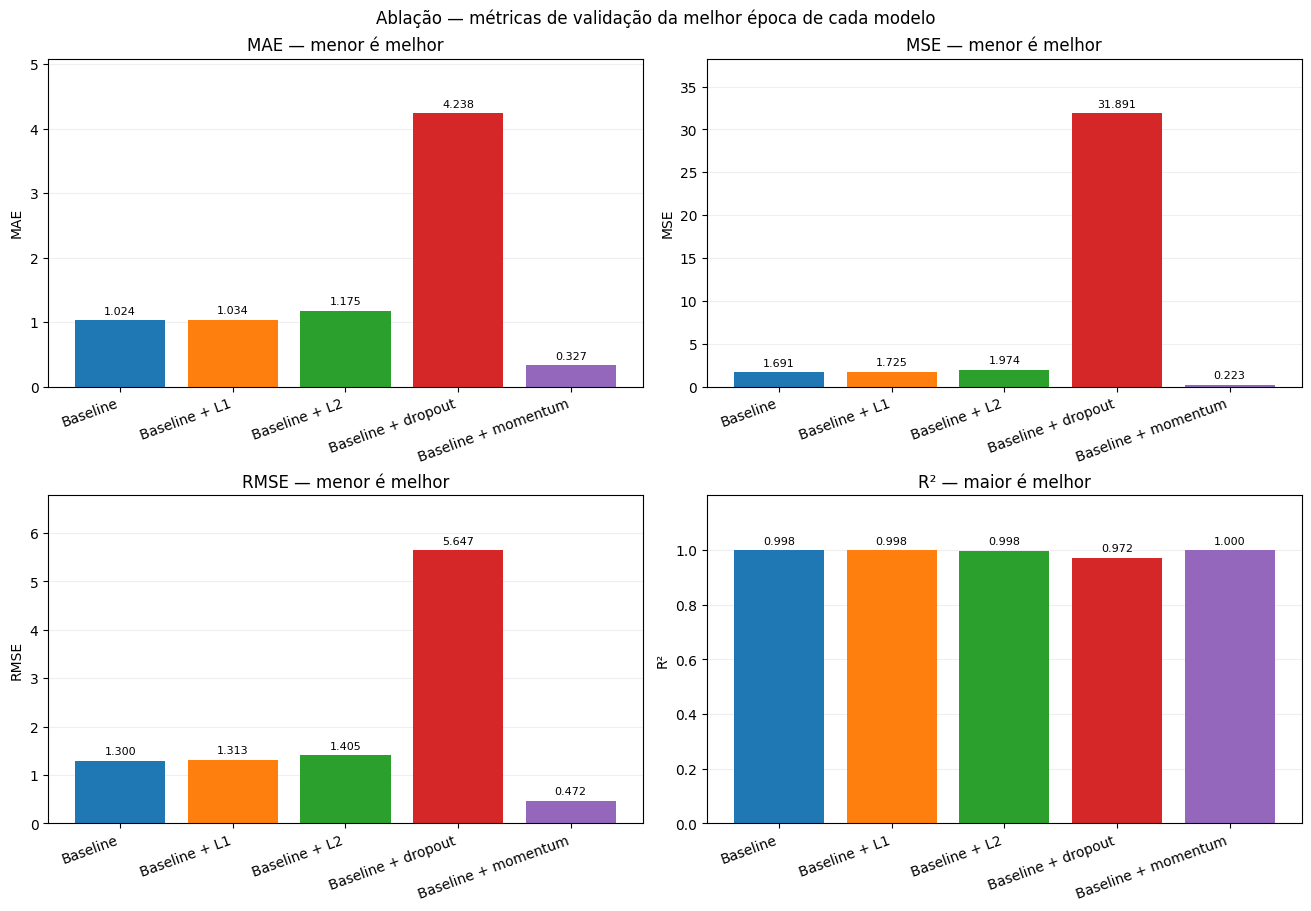

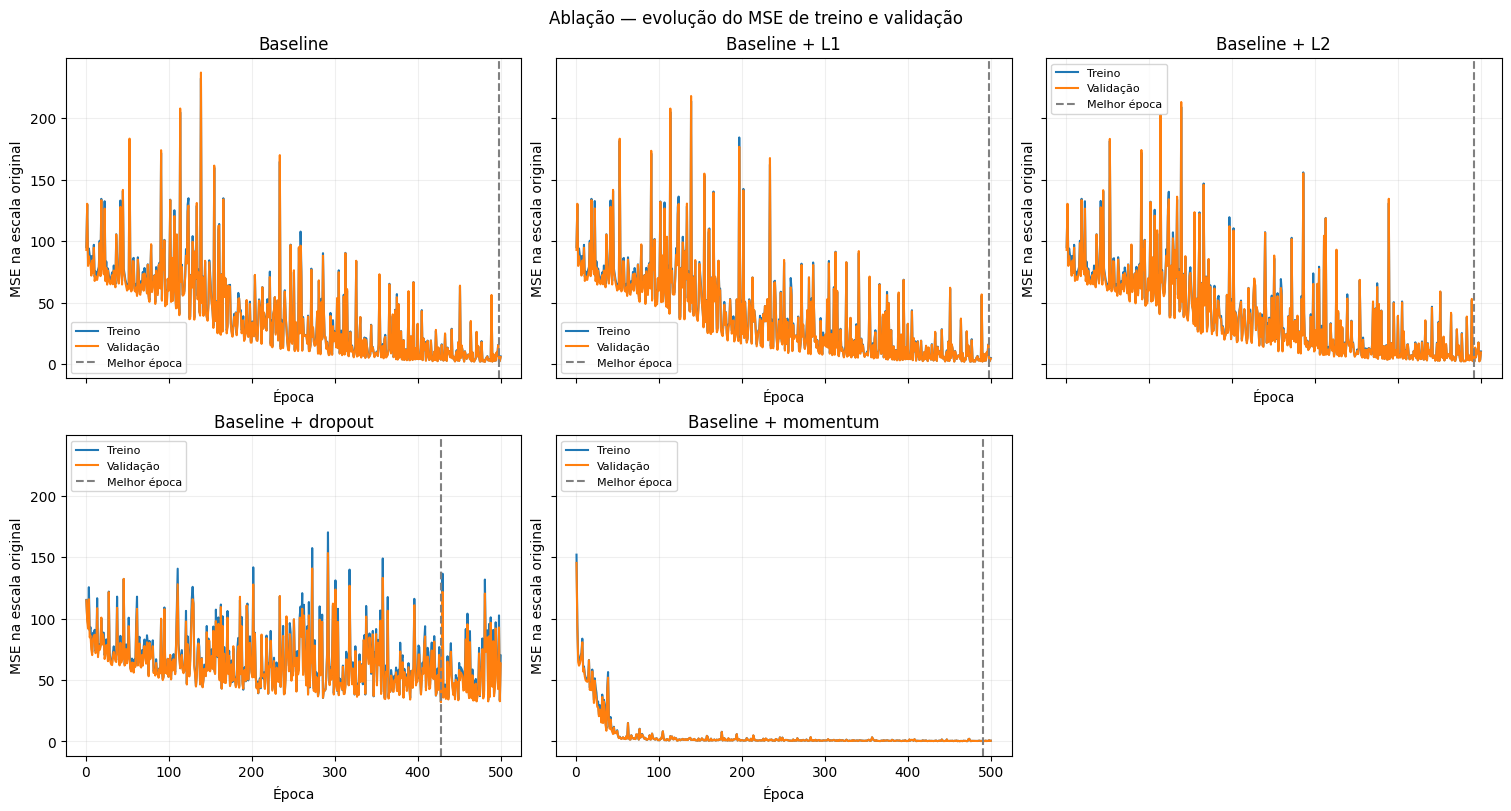

Menor MSE de validação: Baseline + momentum — 0.2230
Redução absoluta em relação ao baseline: 1.4682
Esta comparação usa valores iniciais das técnicas e uma seed; não garante que o vencedor será sempre superior.
Resultados salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\regression\ablacao_20260917_173523_518025


In [28]:
formato_ablacao = {"MAE": "{:.4f}", "MSE": "{:.4f}", "RMSE": "{:.4f}",
                   "R²": "{:.4f}", "Melhor época": "{:.0f}", "Tempo (s)": "{:.1f}"}
display(resultado_ablacoes["tabela"].style.format(formato_ablacao))
plotar_ablacoes(resultado_ablacoes)

melhor_ablacao = resultado_ablacoes["tabela"].sort_values("MSE", kind="stable").iloc[0]
mse_base = resultado_ablacoes["resultados"]["Baseline"]["resumo"]["validacao"]["MSE"]
print(f"Menor MSE de validação: {melhor_ablacao['Modelo']} — {melhor_ablacao['MSE']:.4f}")
print(f"Redução absoluta em relação ao baseline: {mse_base - melhor_ablacao['MSE']:.4f}")
print("Esta comparação usa valores iniciais das técnicas e uma seed; não garante que o vencedor será sempre superior.")
print(f"Resultados salvos em: {resultado_ablacoes['output_dir']}")

## 5. Otimização individual das técnicas

Testamos **quatro valores de cada técnica**, sempre adicionando apenas uma técnica ao baseline. Incluindo o baseline sem técnicas, são **17 treinamentos de 500 épocas**.

In [29]:
#Função para otimizar os valores de L1, L2, dropout e momentum, testando quatro valores distintos para cada técnica.
def otimizar_tecnicas(config_base, valores, treino_ds, validacao_ds, normalizacao, seed=42, device=None, output_dir=None):

    nomes = {"l1": "L1", "l2": "L2", "dropout": "dropout", "momentum": "momentum"}

    if set(valores) != set(nomes):
        raise ValueError("Informe valores para l1, l2, dropout e momentum.")
    for tecnica, opcoes in valores.items():
        if len(opcoes) != 4 or len(set(opcoes)) != 4:
            raise ValueError(f"Informe quatro valores distintos para {tecnica}.")
        for valor in opcoes:
            if not math.isfinite(valor) or valor <= 0:
                raise ValueError("Use valores positivos e finitos; o baseline já representa zero.")
            if tecnica in ("dropout", "momentum") and valor >= 1:
                raise ValueError(f"{tecnica} deve ser menor que 1.")
            
    if output_dir is None:
        output_dir = RESULTS_DIR / (
            "otimizacao_tecnicas_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        )

    casos = {"Baseline": {}}
    identificacao = {}
    for tecnica, opcoes in valores.items():
        for valor in opcoes:
            nome = f"Baseline + {nomes[tecnica]} ({valor:g})"
            casos[nome] = {tecnica: valor}
            identificacao[nome] = (tecnica, valor)

    execucao = executar_ablacoes(config_base, treino_ds, validacao_ds, normalizacao,seed=seed, device=device, output_dir=output_dir, casos=casos)

    tabela = execucao["tabela"].copy()
    tabela["Técnica"] = [identificacao.get(nome, ("baseline", 0.0))[0] for nome in tabela["Modelo"]]
    tabela["Valor"] = [identificacao.get(nome, ("baseline", 0.0))[1] for nome in tabela["Modelo"]]

    selecionadas = []
    mse_base = tabela.loc[tabela["Técnica"] == "baseline", "MSE"].iloc[0]
    tabela["Redução de MSE para baseline"] = mse_base - tabela["MSE"]

    for tecnica in nomes:
        linha = tabela[tabela["Técnica"] == tecnica].sort_values("MSE", kind="stable").iloc[0].copy()
        selecionadas.append(linha)

    melhores = pd.DataFrame(selecionadas).reset_index(drop=True)
    melhores_valores = {linha["Técnica"]: float(linha["Valor"]) for _, linha in melhores.iterrows()}

    pasta = execucao["output_dir"]
    tabela.to_csv(pasta / "todos_valores.csv", index=False)
    melhores.to_csv(pasta / "melhores_por_tecnica.csv", index=False)
    selecao = {"config_base": copy.deepcopy(config_base), 
               "seed": seed,
               "normalizacao": copy.deepcopy(normalizacao),
               "valores_testados": valores, 
               "melhores_valores": melhores_valores,
               "origem": str(pasta)}
    
    (pasta / "selecao.json").write_text(json.dumps(selecao, indent=2, ensure_ascii=False), encoding="utf-8")
    return {**execucao, **selecao, "tabela": tabela, "melhores": melhores}

In [30]:
def plotar_otimizacao_tecnicas(resultado):
    tabela = resultado["tabela"]
    base = tabela[tabela["Técnica"] == "baseline"].iloc[0]
    tecnicas = ("l1", "l2", "dropout", "momentum")
    metricas = ("MAE", "MSE", "RMSE", "R²")
    fig, axes = plt.subplots(4, 4, figsize=(17, 14), layout="constrained")
    for linha, tecnica in enumerate(tecnicas):
        dados_tecnica = tabela[tabela["Técnica"] == tecnica].sort_values("Valor")
        for coluna, metrica in enumerate(metricas):
            ax = axes[linha, coluna]
            ax.plot(dados_tecnica["Valor"], dados_tecnica[metrica], marker="o", label="Baseline + técnica")
            ax.axhline(base[metrica], color="gray", linestyle="--", label="Baseline")
            ax.axvline(resultado["melhores_valores"][tecnica], color="tab:orange",
                       linestyle=":", label="Valor escolhido pelo MSE")
            if tecnica in ("l1", "l2"):
                ax.set_xscale("log")
            ax.set_xticks(dados_tecnica["Valor"], [f"{v:g}" for v in dados_tecnica["Valor"]])
            direcao = "maior é melhor" if metrica == "R²" else "menor é melhor"
            ax.set(title=f"{tecnica.upper() if tecnica in ('l1', 'l2') else tecnica} — {metrica}",
                   xlabel="Valor da técnica", ylabel=f"{metrica} ({direcao})")
            ax.grid(alpha=0.2)
            ax.legend(fontsize=7)
    fig.suptitle("Otimização individual das técnicas — métricas na validação", fontsize=16)
    for ext in ("png", "pdf"):
        fig.savefig(resultado["output_dir"] / f"otimizacao_tecnicas.{ext}", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [31]:
config_otimizacao_tecnicas = copy.deepcopy(optuna_best["config"])
config_otimizacao_tecnicas["epochs"] = 500
valores_tecnicas = {
    "l1": [1e-7, 1e-6, 1e-5, 1e-4],
    "l2": [1e-5, 1e-4, 1e-3, 1e-2],
    "dropout": [0.1, 0.2, 0.3, 0.5],
    "momentum": [0.3, 0.5, 0.7, 0.9],
}
resultado_otimizacao_tecnicas = otimizar_tecnicas(config_otimizacao_tecnicas, valores_tecnicas,treino_ds, validacao_ds, normalizacao, seed=SEED, device=DEVICE)

(resultado_otimizacao_tecnicas["output_dir"] / "origem.json").write_text(json.dumps({
    "checkpoint_optuna": str(optuna_best["checkpoint"]),
}, indent=2), encoding="utf-8")

Iniciando Baseline (1/17)...
Baseline | Melhor época: 498 | MSE validação: 1.6912 | Tempo: 32.5s
Iniciando Baseline + L1 (1e-07) (2/17)...
Baseline + L1 (1e-07) | Melhor época: 481 | MSE validação: 1.7033 | Tempo: 42.9s
Iniciando Baseline + L1 (1e-06) (3/17)...
Baseline + L1 (1e-06) | Melhor época: 498 | MSE validação: 1.7250 | Tempo: 43.1s
Iniciando Baseline + L1 (1e-05) (4/17)...
Baseline + L1 (1e-05) | Melhor época: 498 | MSE validação: 1.8446 | Tempo: 42.9s
Iniciando Baseline + L1 (0.0001) (5/17)...
Baseline + L1 (0.0001) | Melhor época: 482 | MSE validação: 3.9979 | Tempo: 43.0s
Iniciando Baseline + L2 (1e-05) (6/17)...
Baseline + L2 (1e-05) | Melhor época: 498 | MSE validação: 1.7120 | Tempo: 44.3s
Iniciando Baseline + L2 (0.0001) (7/17)...
Baseline + L2 (0.0001) | Melhor época: 492 | MSE validação: 1.9744 | Tempo: 44.7s
Iniciando Baseline + L2 (0.001) (8/17)...
Baseline + L2 (0.001) | Melhor época: 487 | MSE validação: 6.7716 | Tempo: 44.6s
Iniciando Baseline + L2 (0.01) (9/17).

140

,Modelo,MAE,MSE,RMSE,R²,Melhor época,Tempo (s),Técnica,Valor,Redução de MSE para baseline
0,Baseline,1.0244,1.6912,1.3005,0.9985,498,32.5,baseline,0,+0.0000
1,Baseline + L1 (1e-07),1.0460,1.7033,1.3051,0.9985,481,42.9,l1,1e-07,-0.0120
2,Baseline + L1 (1e-06),1.0344,1.7250,1.3134,0.9985,498,43.1,l1,1e-06,-0.0338
3,Baseline + L1 (1e-05),1.0765,1.8446,1.3582,0.9984,498,42.9,l1,1e-05,-0.1533
4,Baseline + L1 (0.0001),1.5969,3.9979,1.9995,0.9964,482,43.0,l1,0.0001,-2.3066
5,Baseline + L2 (1e-05),1.0349,1.7120,1.3084,0.9985,498,44.3,l2,1e-05,-0.0208
6,Baseline + L2 (0.0001),1.1750,1.9744,1.4051,0.9982,492,44.7,l2,0.0001,-0.2831
7,Baseline + L2 (0.001),2.2131,6.7716,2.6022,0.9940,487,44.6,l2,0.001,-5.0804
8,Baseline + L2 (0.01),6.6536,64.7505,8.0468,0.9425,109,45.0,l2,0.01,-63.0592
9,Baseline + dropout (0.1),3.0009,15.6679,3.9583,0.9861,451,35.2,dropout,0.1,-13.9767


Melhor valor encontrado para cada técnica:


,Técnica,Valor,MAE,MSE,RMSE,R²,Redução de MSE para baseline
0,l1,1e-07,1.0460,1.7033,1.3051,0.9985,-0.0120
1,l2,1e-05,1.0349,1.7120,1.3084,0.9985,-0.0208
2,dropout,0.1,3.0009,15.6679,3.9583,0.9861,-13.9767
3,momentum,0.9,0.3273,0.2230,0.4722,0.9998,+1.4682


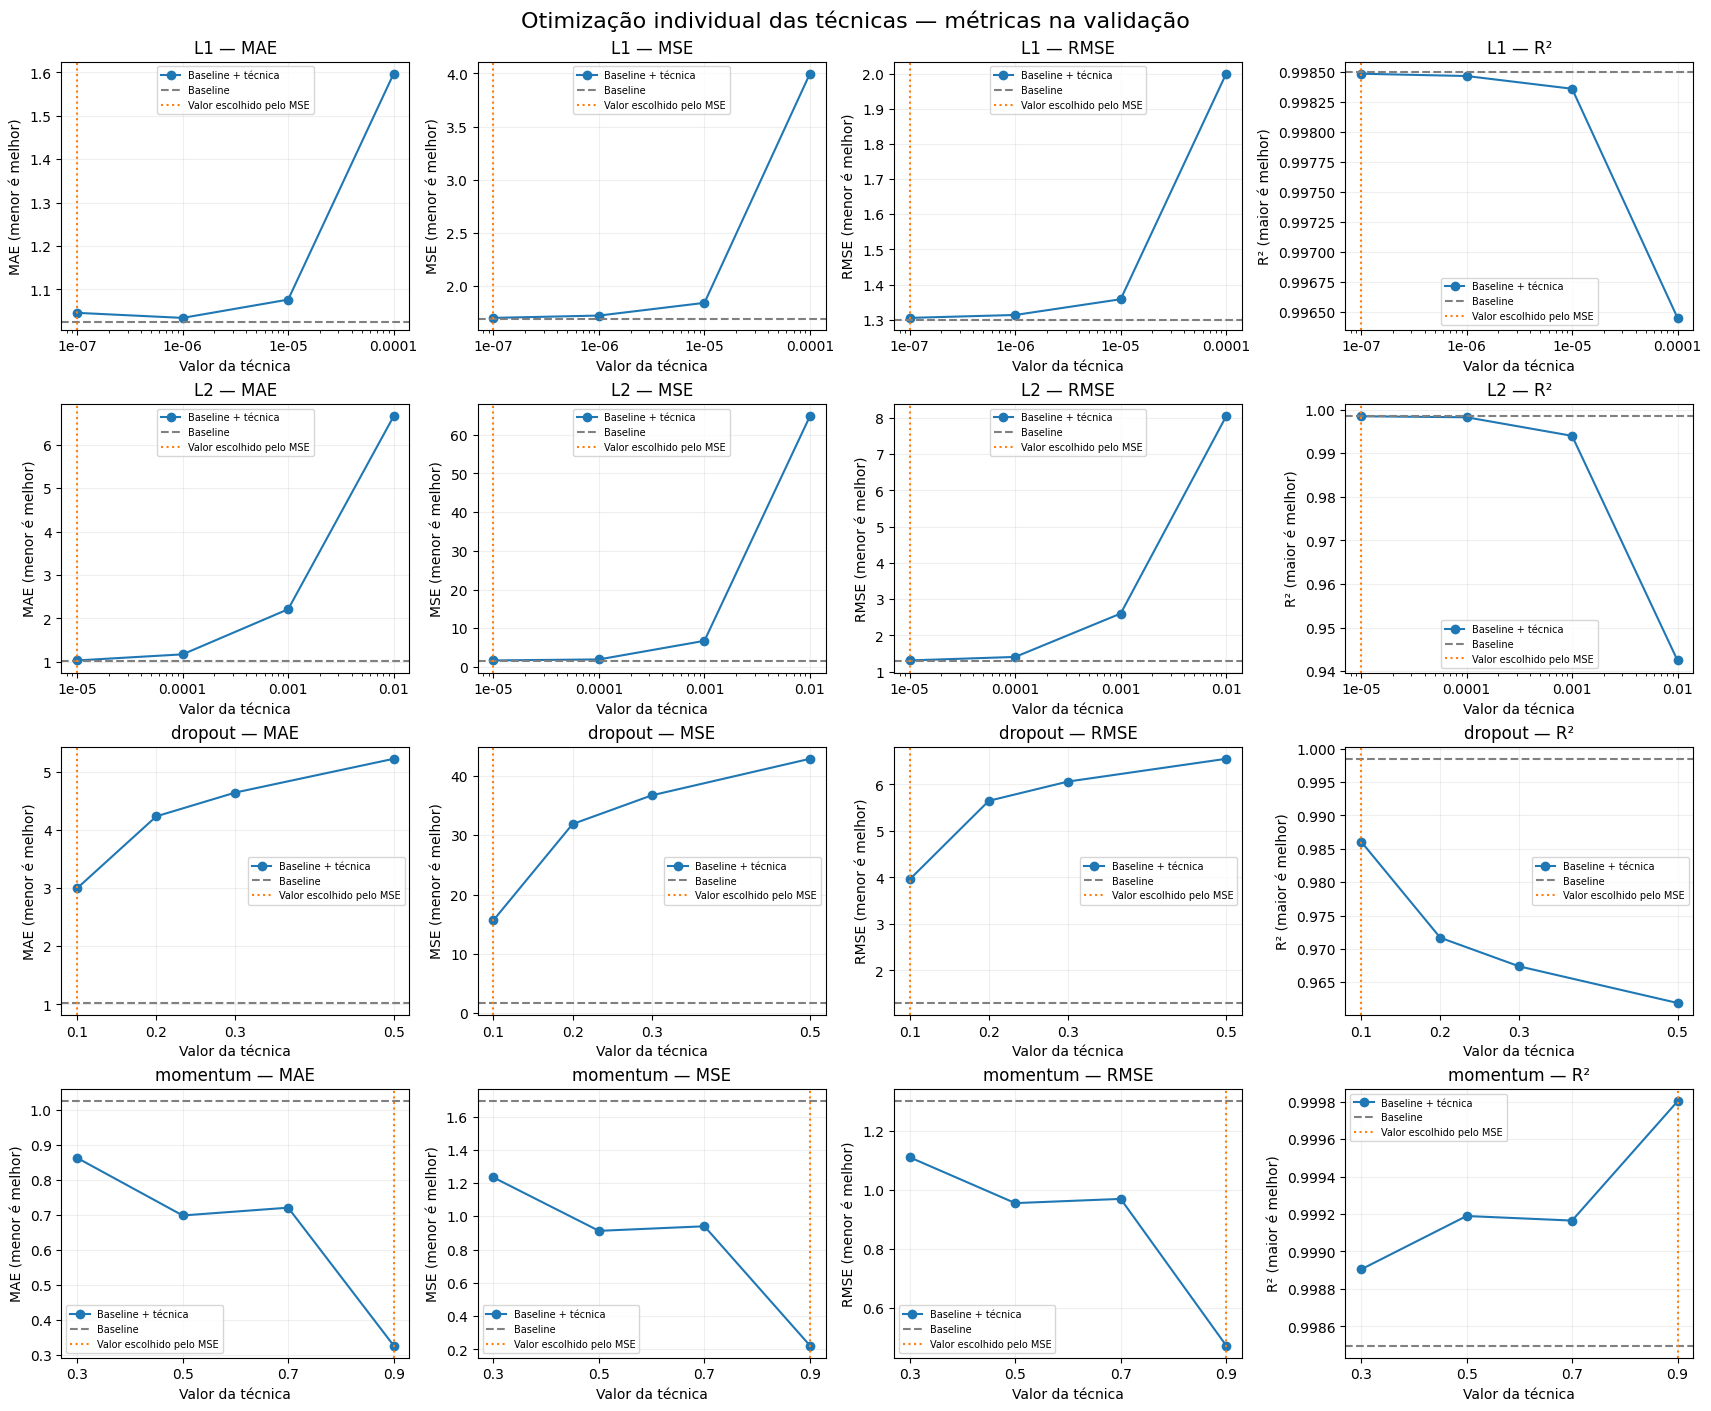

Resultados salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\regression\otimizacao_tecnicas_20260917_173833_324291


In [32]:
formato_tecnicas = {
    "MAE": "{:.4f}", "MSE": "{:.4f}", "RMSE": "{:.4f}", "R²": "{:.4f}",
    "Valor": "{:.6g}", "Melhor época": "{:.0f}", "Tempo (s)": "{:.1f}",
    "Redução de MSE para baseline": "{:+.4f}",
}

display(resultado_otimizacao_tecnicas["tabela"].style.format(formato_tecnicas))
print("Melhor valor encontrado para cada técnica:")

display(resultado_otimizacao_tecnicas["melhores"][[
    "Técnica", "Valor", "MAE", "MSE", "RMSE", "R²", "Redução de MSE para baseline",
]].style.format(formato_tecnicas))

plotar_otimizacao_tecnicas(resultado_otimizacao_tecnicas)
print(f"Resultados salvos em: {resultado_otimizacao_tecnicas['output_dir']}")

## 6. Combinações das técnicas

Vamos avaliar as **16 combinações** de L1, L2, dropout e momentum: o baseline, quatro casos individuais, seis pares, quatro trios e todas as técnicas juntas, com os melhores valores encontrados anteriormente.

In [33]:
from itertools import combinations

def gerar_combinacoes(l1=1e-7, l2=1e-5, dropout=0.1, momentum=0.9):
    tecnicas = {
        "L1": ("l1", l1), 
        "L2": ("l2", l2),
        "dropout": ("dropout", dropout), 
        "momentum": ("momentum", momentum),
    }
    casos = {}
    for quantidade in range(5):
        for grupo in combinations(tecnicas, quantidade):
            nome = "Baseline" + (" + " + " + ".join(grupo) if grupo else "")
            casos[nome] = dict(tecnicas[tecnica] for tecnica in grupo)
    return casos

In [34]:
config_combinacoes = copy.deepcopy(resultado_otimizacao_tecnicas["config_base"])
casos_combinacoes = gerar_combinacoes(**resultado_otimizacao_tecnicas["melhores_valores"])

pasta_combinacoes = RESULTS_DIR / (
    "combinacoes_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)

pasta_combinacoes.mkdir(parents=True, exist_ok=True)
(pasta_combinacoes / "origem_otimizacao.json").write_text(json.dumps({
    "arquivo_selecao": str(resultado_otimizacao_tecnicas["output_dir"] / "selecao.json"),
    "melhores_valores": resultado_otimizacao_tecnicas["melhores_valores"],
    "config_base": config_combinacoes,
    "normalizacao": resultado_otimizacao_tecnicas["normalizacao"],
    "seed": resultado_otimizacao_tecnicas["seed"],
}, indent=2, ensure_ascii=False), encoding="utf-8")
resultado_combinacoes = executar_ablacoes(
    config_combinacoes, treino_ds, validacao_ds, resultado_otimizacao_tecnicas["normalizacao"],
    seed=resultado_otimizacao_tecnicas["seed"], device=DEVICE,
    output_dir=pasta_combinacoes, casos=casos_combinacoes,
)

Iniciando Baseline (1/16)...
Baseline | Melhor época: 498 | MSE validação: 1.6912 | Tempo: 32.6s
Iniciando Baseline + L1 (2/16)...
Baseline + L1 | Melhor época: 481 | MSE validação: 1.7033 | Tempo: 43.4s
Iniciando Baseline + L2 (3/16)...
Baseline + L2 | Melhor época: 498 | MSE validação: 1.7120 | Tempo: 44.4s
Iniciando Baseline + dropout (4/16)...
Baseline + dropout | Melhor época: 451 | MSE validação: 15.6679 | Tempo: 35.3s
Iniciando Baseline + momentum (5/16)...
Baseline + momentum | Melhor época: 491 | MSE validação: 0.2230 | Tempo: 32.5s
Iniciando Baseline + L1 + L2 (6/16)...
Baseline + L1 + L2 | Melhor época: 498 | MSE validação: 1.7781 | Tempo: 54.4s
Iniciando Baseline + L1 + dropout (7/16)...
Baseline + L1 + dropout | Melhor época: 451 | MSE validação: 15.9712 | Tempo: 46.2s
Iniciando Baseline + L1 + momentum (8/16)...
Baseline + L1 + momentum | Melhor época: 466 | MSE validação: 0.4021 | Tempo: 43.5s
Iniciando Baseline + L2 + dropout (9/16)...
Baseline + L2 + dropout | Melhor é

,Modelo,MAE,MSE,RMSE,R²,Melhor época,Tempo (s)
4,Baseline + momentum,0.3273,0.2230,0.4722,0.9998,491,32.5
7,Baseline + L1 + momentum,0.4266,0.4021,0.6341,0.9996,466,43.5
12,Baseline + L1 + L2 + momentum,0.4598,0.4630,0.6805,0.9996,466,54.8
9,Baseline + L2 + momentum,0.5126,0.5364,0.7324,0.9995,491,45.2
0,Baseline,1.0244,1.6912,1.3005,0.9985,498,32.6
1,Baseline + L1,1.0460,1.7033,1.3051,0.9985,481,43.4
2,Baseline + L2,1.0349,1.7120,1.3084,0.9985,498,44.4
5,Baseline + L1 + L2,1.0510,1.7781,1.3334,0.9984,498,54.4
15,Baseline + L1 + L2 + dropout + momentum,2.5960,11.0046,3.3173,0.9902,464,64.9
10,Baseline + dropout + momentum,2.5263,11.8015,3.4353,0.9895,418,36.0


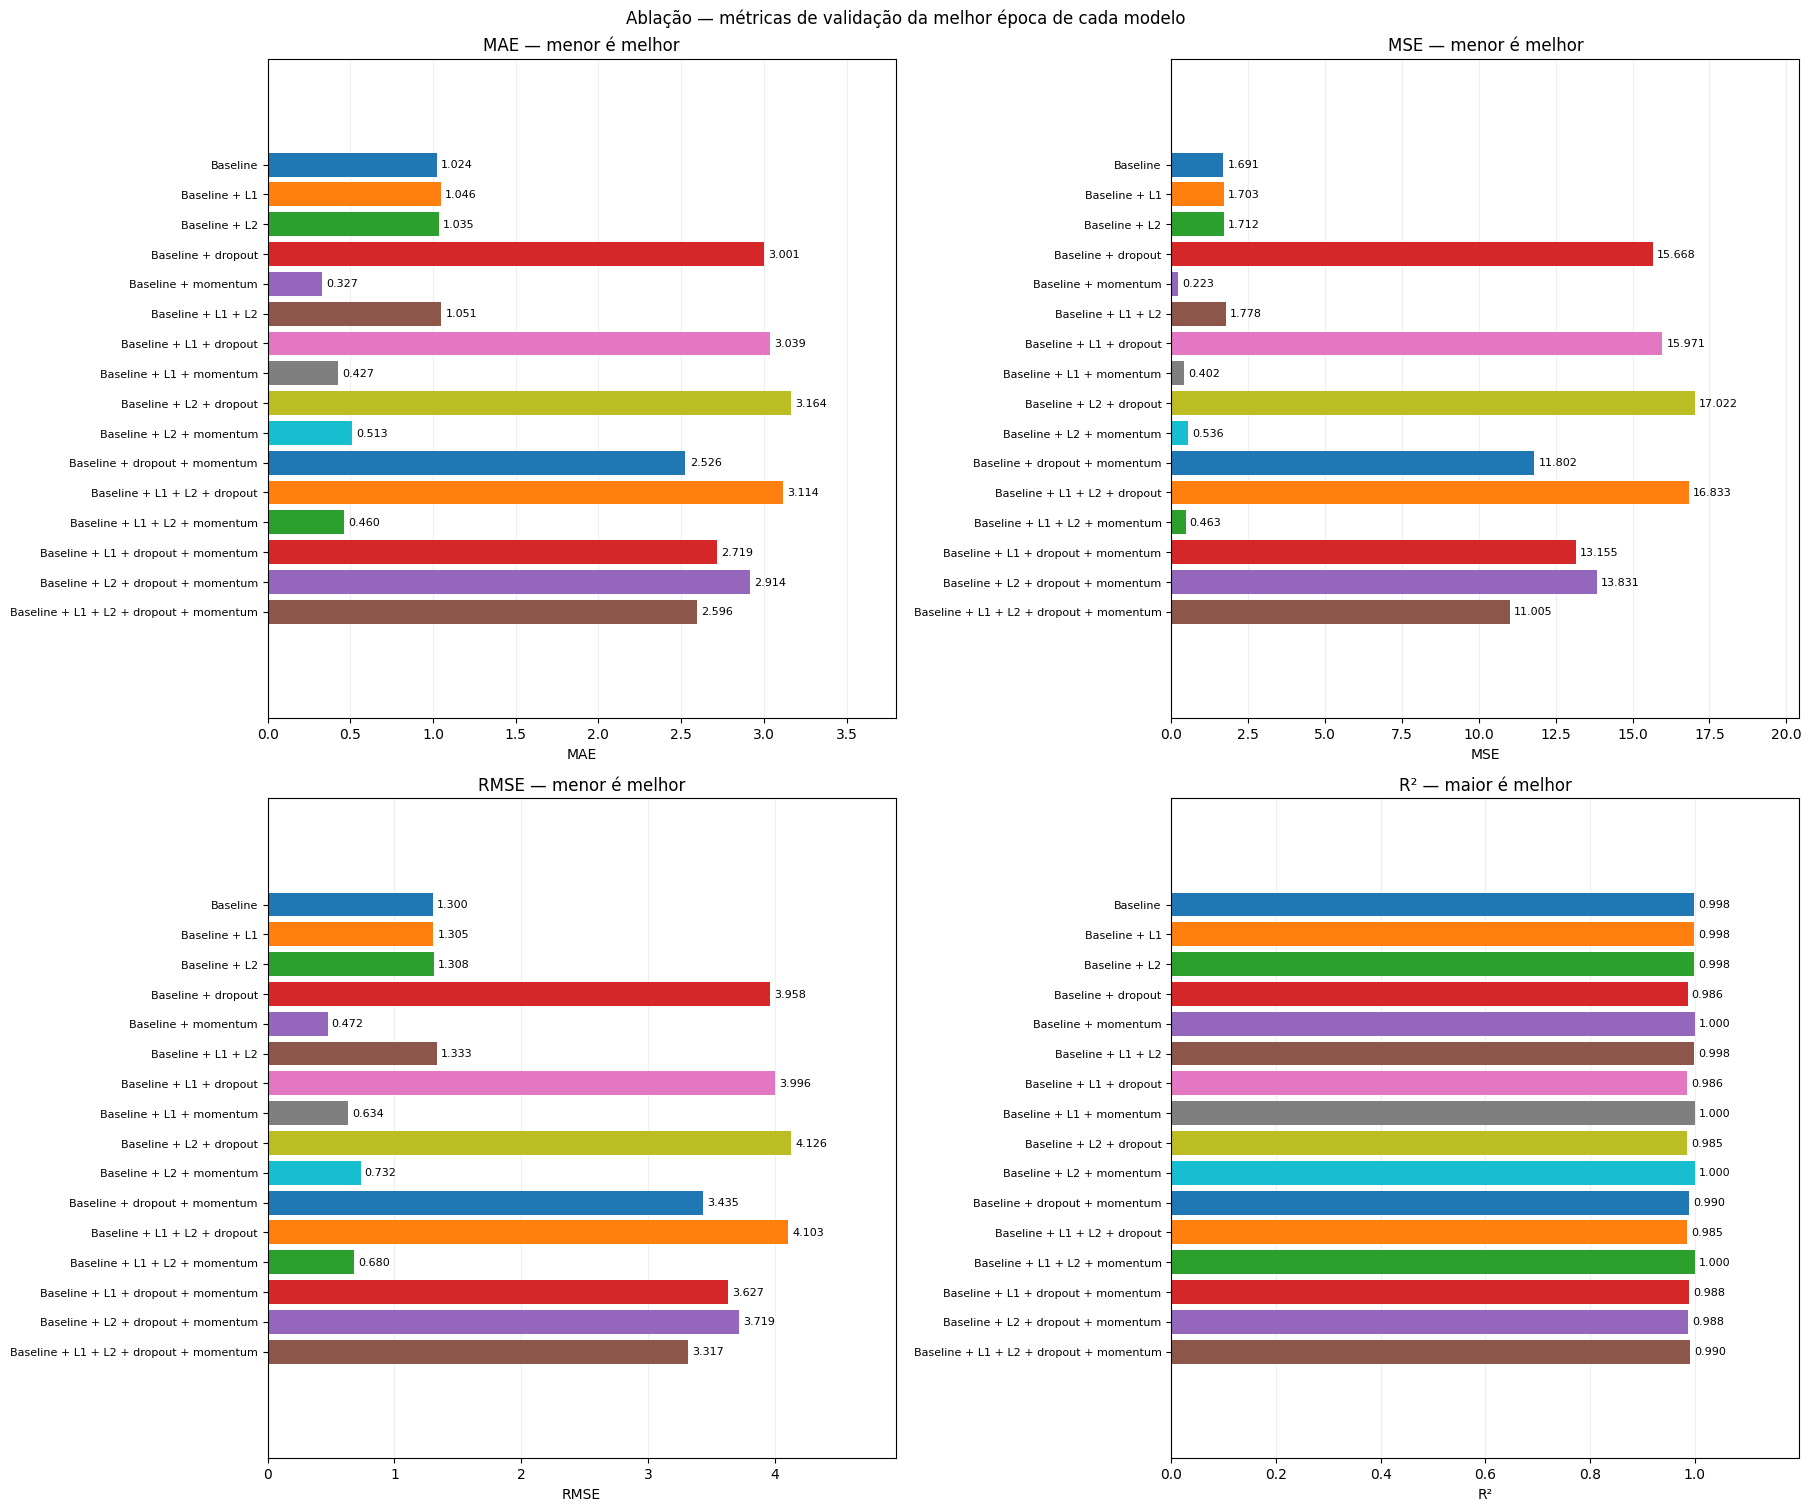

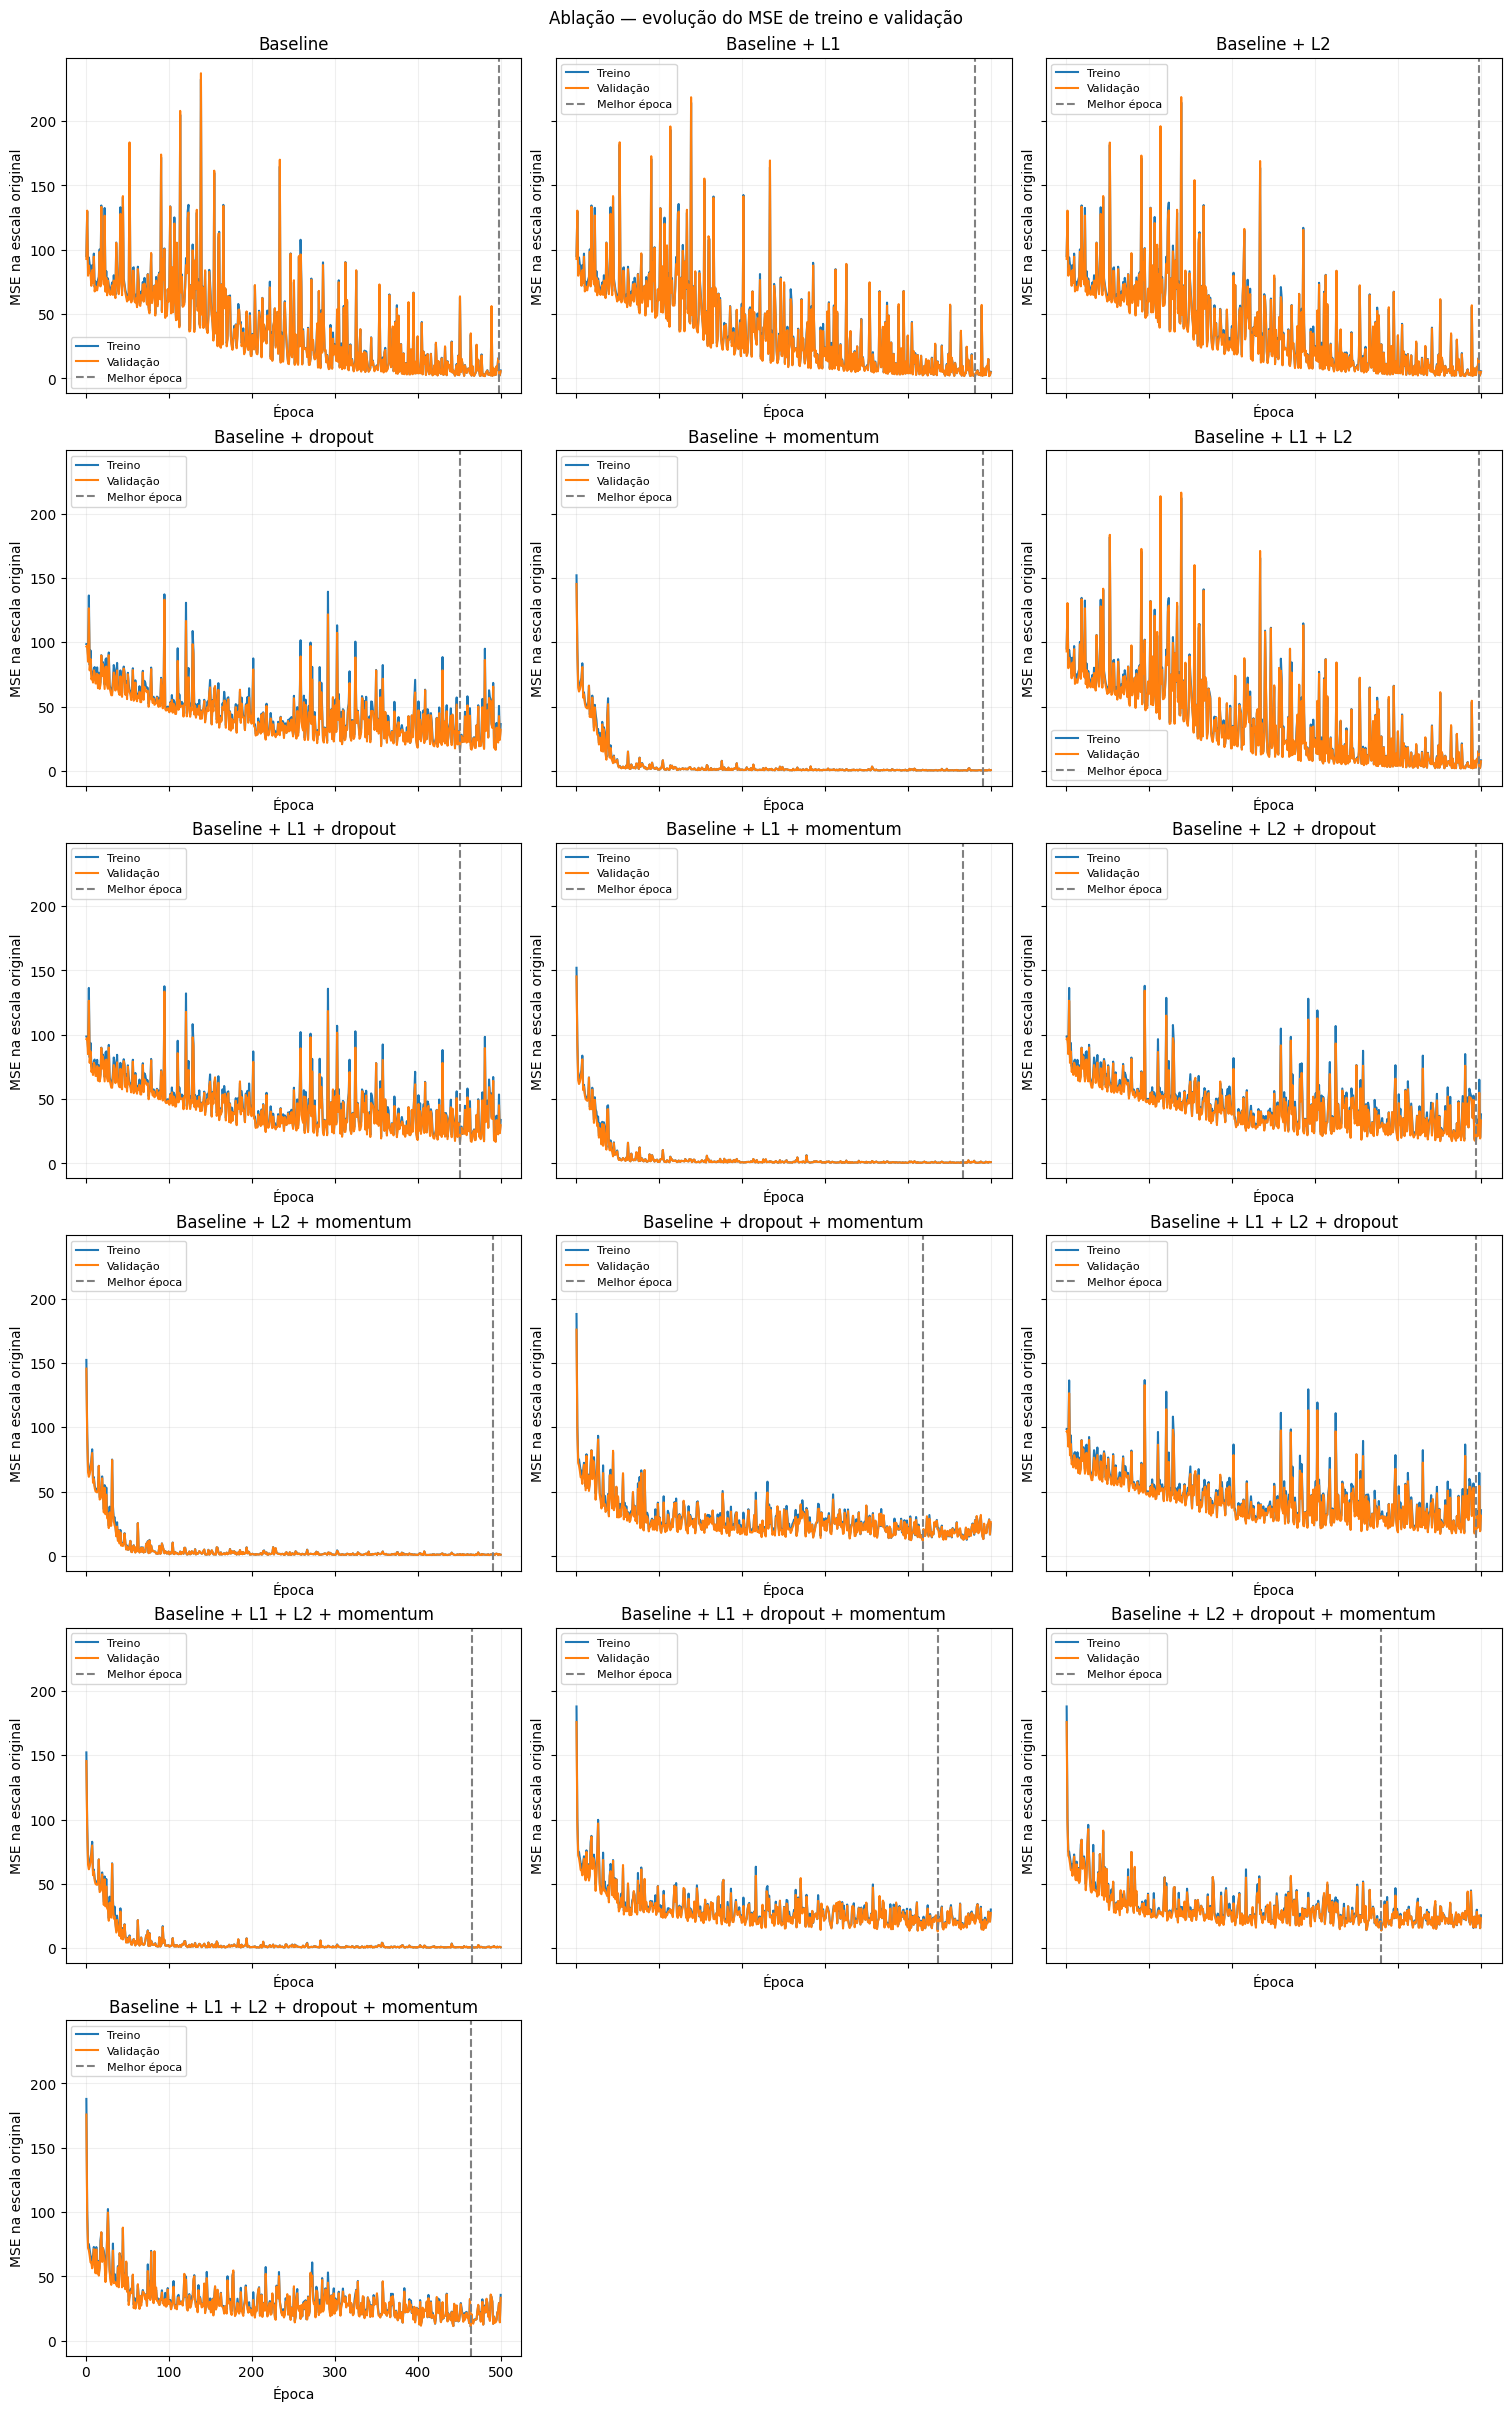

Modelo final selecionado na validação: Baseline + momentum
MSE: 0.2230 | Melhor época: 491
Resultados salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\regression\combinacoes_20260917_174933_692138


In [35]:
formato_combinacoes = {"MAE": "{:.4f}", "MSE": "{:.4f}", "RMSE": "{:.4f}",
                       "R²": "{:.4f}", "Melhor época": "{:.0f}", "Tempo (s)": "{:.1f}"}
display(resultado_combinacoes["tabela"].sort_values("MSE", kind="stable").style.format(formato_combinacoes))
plotar_ablacoes(resultado_combinacoes)

melhor_combinacao = resultado_combinacoes["tabela"].sort_values("MSE", kind="stable").iloc[0]
resultado_modelo_final = resultado_combinacoes["resultados"][melhor_combinacao["Modelo"]]

modelo_final = {
    "nome": melhor_combinacao["Modelo"],
    "config": copy.deepcopy(resultado_modelo_final["resumo"]["config"]),
    "checkpoint": Path(resultado_modelo_final["output_dir"]) / "melhor_modelo.pt",
}

print(f"Modelo final selecionado na validação: {modelo_final['nome']}")
print(f"MSE: {melhor_combinacao['MSE']:.4f} | Melhor época: {resultado_modelo_final['resumo']['melhor_epoca']}")
(resultado_combinacoes["output_dir"] / "modelo_final.json").write_text(json.dumps({
    **modelo_final, "checkpoint": str(modelo_final["checkpoint"]),
    "mse_validacao": float(melhor_combinacao["MSE"]),
    "melhor_epoca": resultado_modelo_final["resumo"]["melhor_epoca"],
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Resultados salvos em: {resultado_combinacoes['output_dir']}")

## 7. Avaliação final no teste

Comparamos os checkpoints da **configuração inicial**, do **baseline final do Optuna** e do **modelo final das combinações**, selecionados anteriormente pela validação. Os três modelos serão avaliados nas mesmas amostras de teste, sem treinar novamente, com **MAE, MSE, RMSE e R² na escala original de y**.

In [36]:
def avaliar_checkpoint_regressao(caminho, x_teste, y_teste, x_curva, device=None):
    checkpoint = torch.load(caminho, map_location="cpu", weights_only=True)
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    modelo = criar_modelo_ablacao(checkpoint["config"]).to(device)
    modelo.load_state_dict(checkpoint["model_state_dict"])
    modelo.eval()
    previsoes = prever(modelo, x_teste, checkpoint["normalizacao"])
    alvos = np.asarray(y_teste, dtype=float).ravel()
    mse = float(mean_squared_error(alvos, previsoes))
    metricas = {"MAE": float(mean_absolute_error(alvos, previsoes)), "MSE": mse,
                "RMSE": math.sqrt(mse), "R²": float(r2_score(alvos, previsoes))}
    detalhes = {
        "checkpoint": str(caminho), "config": checkpoint["config"],
        "normalizacao": checkpoint["normalizacao"], "seed": checkpoint["seed"],
        "melhor_epoca": checkpoint["epoch"], "mse_validacao": checkpoint["val_mse"],
        "amostras_teste": len(alvos), "metricas_teste": metricas,
    }
    curva = prever(modelo, x_curva, checkpoint["normalizacao"])
    return {"metricas": metricas, "detalhes": detalhes, "previsoes": previsoes,
            "residuos": alvos - previsoes, "curva": curva}

In [37]:
checkpoints_finais = {
    "Configuração inicial": Path(busca_optuna["resultado_inicial"]["output_dir"]) / "melhor_modelo.pt",
    "Baseline final": optuna_best["checkpoint"],
    "Modelo final": modelo_final["checkpoint"],
}
avaliacoes_finais = {
    nome: avaliar_checkpoint_regressao(
        caminho, dados["Teste"]["x"], dados["Teste"]["y"], x_curva, device=DEVICE,
    ) for nome, caminho in checkpoints_finais.items()
}
tabela_final = pd.DataFrame({nome: r["metricas"] for nome, r in avaliacoes_finais.items()}).T
tabela_final.index.name = "Modelo"
print(f"Avaliação no teste — modelo final: {modelo_final['nome']}")
display(tabela_final.style.format("{:.4f}"))

pasta_teste_final = Path(resultado_combinacoes["output_dir"]) / "teste_final"
pasta_teste_final.mkdir(parents=True, exist_ok=True)
tabela_final.to_csv(pasta_teste_final / "comparacao_teste.csv")
(pasta_teste_final / "detalhes.json").write_text(json.dumps({
    "combinacao_selecionada": modelo_final["nome"],
    "modelos": {nome: r["detalhes"] for nome, r in avaliacoes_finais.items()},
}, indent=2, ensure_ascii=False), encoding="utf-8")
pd.DataFrame({
    "x": dados["Teste"]["x"].ravel(), "y_real": dados["Teste"]["y"].ravel(),
    **{nome: r["previsoes"] for nome, r in avaliacoes_finais.items()},
}).to_csv(pasta_teste_final / "previsoes_teste.csv", index=False)
print(f"Resultados salvos em: {pasta_teste_final}")

Avaliação no teste — modelo final: Baseline + momentum


,MAE,MSE,RMSE,R²
Modelo,,,,
Configuração inicial,3.9123,21.8427,4.6736,0.9806
Baseline final,1.0374,1.8266,1.3515,0.9984
Modelo final,0.3474,0.2587,0.5086,0.9998


Resultados salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\regression\combinacoes_20260917_174933_692138\teste_final


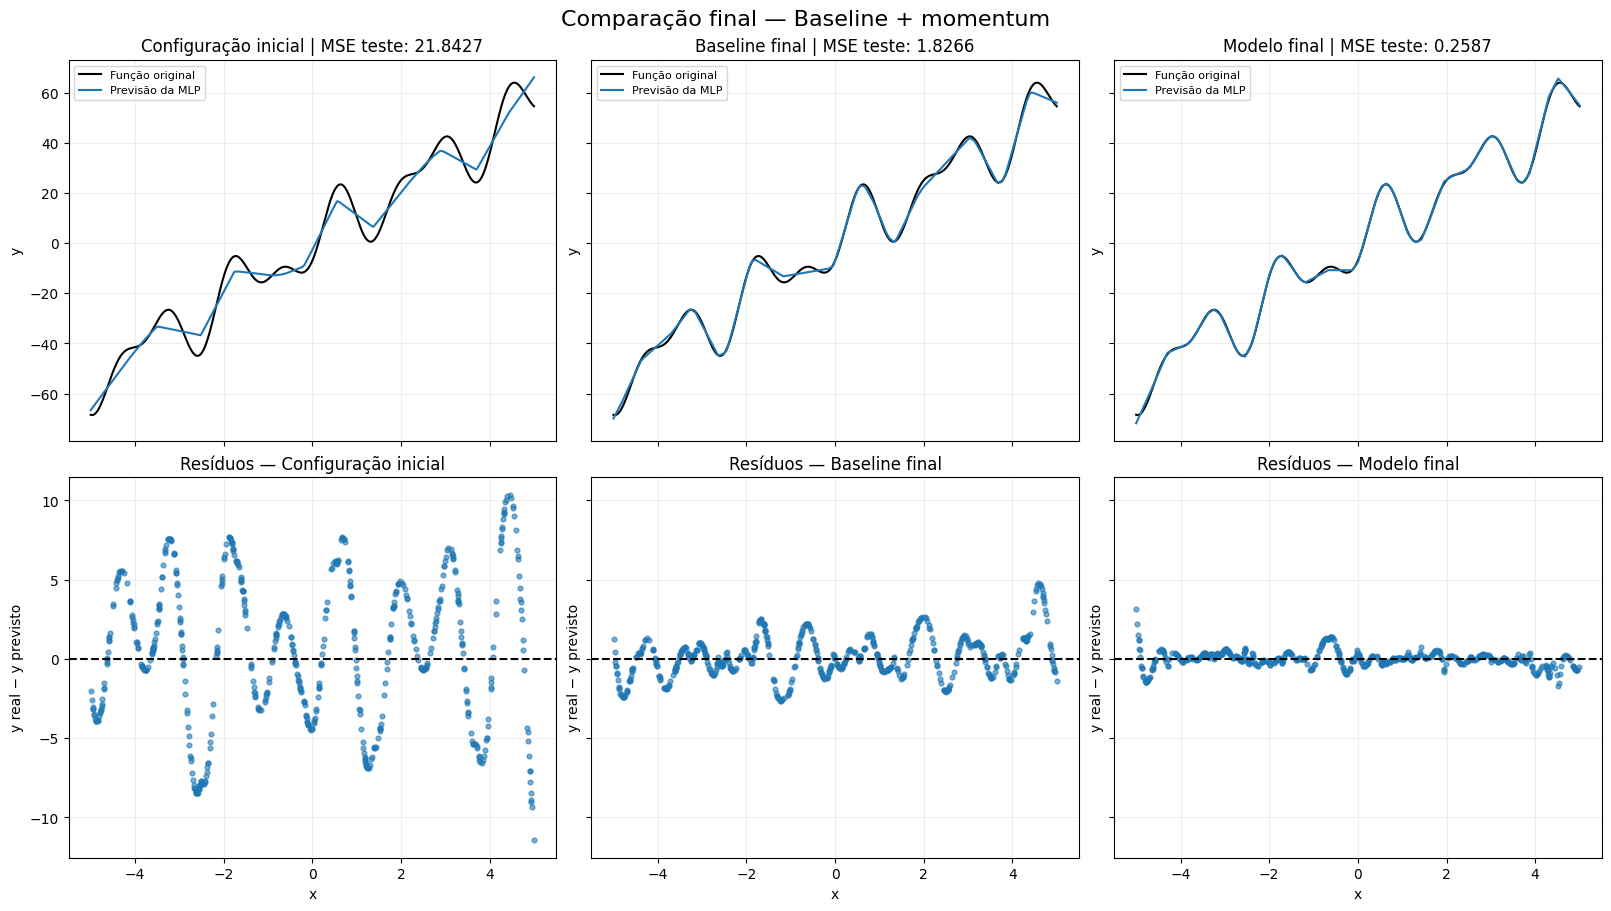

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey="row", layout="constrained")
for coluna, (nome, r) in enumerate(avaliacoes_finais.items()):
    ax = axes[0, coluna]
    ax.plot(x_curva, funcao_alvo(x_curva), color="black", label="Função original")
    ax.plot(x_curva, r["curva"], color="tab:blue", label="Previsão da MLP")
    ax.set(title=f"{nome} | MSE teste: {r['metricas']['MSE']:.4f}", ylabel="y")
    ax.legend(fontsize=8)
    ax = axes[1, coluna]
    ax.scatter(dados["Teste"]["x"].ravel(), r["residuos"], s=12, alpha=0.6)
    ax.axhline(0, color="black", linestyle="--")
    ax.set(title=f"Resíduos — {nome}", xlabel="x", ylabel="y real − y previsto")
for ax in axes.ravel():
    ax.grid(alpha=0.2)
fig.suptitle(f"Comparação final — {modelo_final['nome']}", fontsize=16)
for ext in ("png", "pdf"):
    fig.savefig(pasta_teste_final / f"comparacao_funcao_residuos.{ext}", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

In [39]:
checkpoint_final_evolucao = torch.load(modelo_final["checkpoint"], map_location="cpu", weights_only=True)
escala_final_evolucao = checkpoint_final_evolucao["normalizacao"]
# Reutiliza os mesmos dados e a escala registrada no checkpoint vencedor.
treino_evolucao_final = preparar_tensores(**dados["Treino"], normalizacao=escala_final_evolucao)
validacao_evolucao_final = preparar_tensores(**dados["Validação"], normalizacao=escala_final_evolucao)
pasta_evolucao_final = Path(resultado_combinacoes["output_dir"]) / (
    "evolucao_modelo_final_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
registro_evolucao_final = registrar_evolucao(
    checkpoint_final_evolucao["config"], treino_evolucao_final, validacao_evolucao_final,
    escala_final_evolucao, x_curva, seed=checkpoint_final_evolucao["seed"], device=DEVICE,
    output_dir=pasta_evolucao_final, funcao_treino=treinar_ablacao,
)
(pasta_evolucao_final / "origem.json").write_text(json.dumps({
    "modelo_final": modelo_final["nome"], "checkpoint_original": str(modelo_final["checkpoint"]),
    "melhor_epoca_original": checkpoint_final_evolucao["epoch"],
    "mse_validacao_original": checkpoint_final_evolucao["val_mse"],
    "mse_validacao_reexecucao": registro_evolucao_final["resultado"]["resumo"]["validacao"]["MSE"],
    "device_reexecucao": registro_evolucao_final["resultado"]["resumo"]["device"],
}, indent=2, ensure_ascii=False), encoding="utf-8")

Registrando evolução: época 0/500
Registrando evolução: época 50/500
Registrando evolução: época 100/500
Registrando evolução: época 150/500
Registrando evolução: época 200/500
Registrando evolução: época 250/500
Registrando evolução: época 300/500
Registrando evolução: época 350/500
Registrando evolução: época 400/500
Registrando evolução: época 450/500
Registrando evolução: época 500/500


375

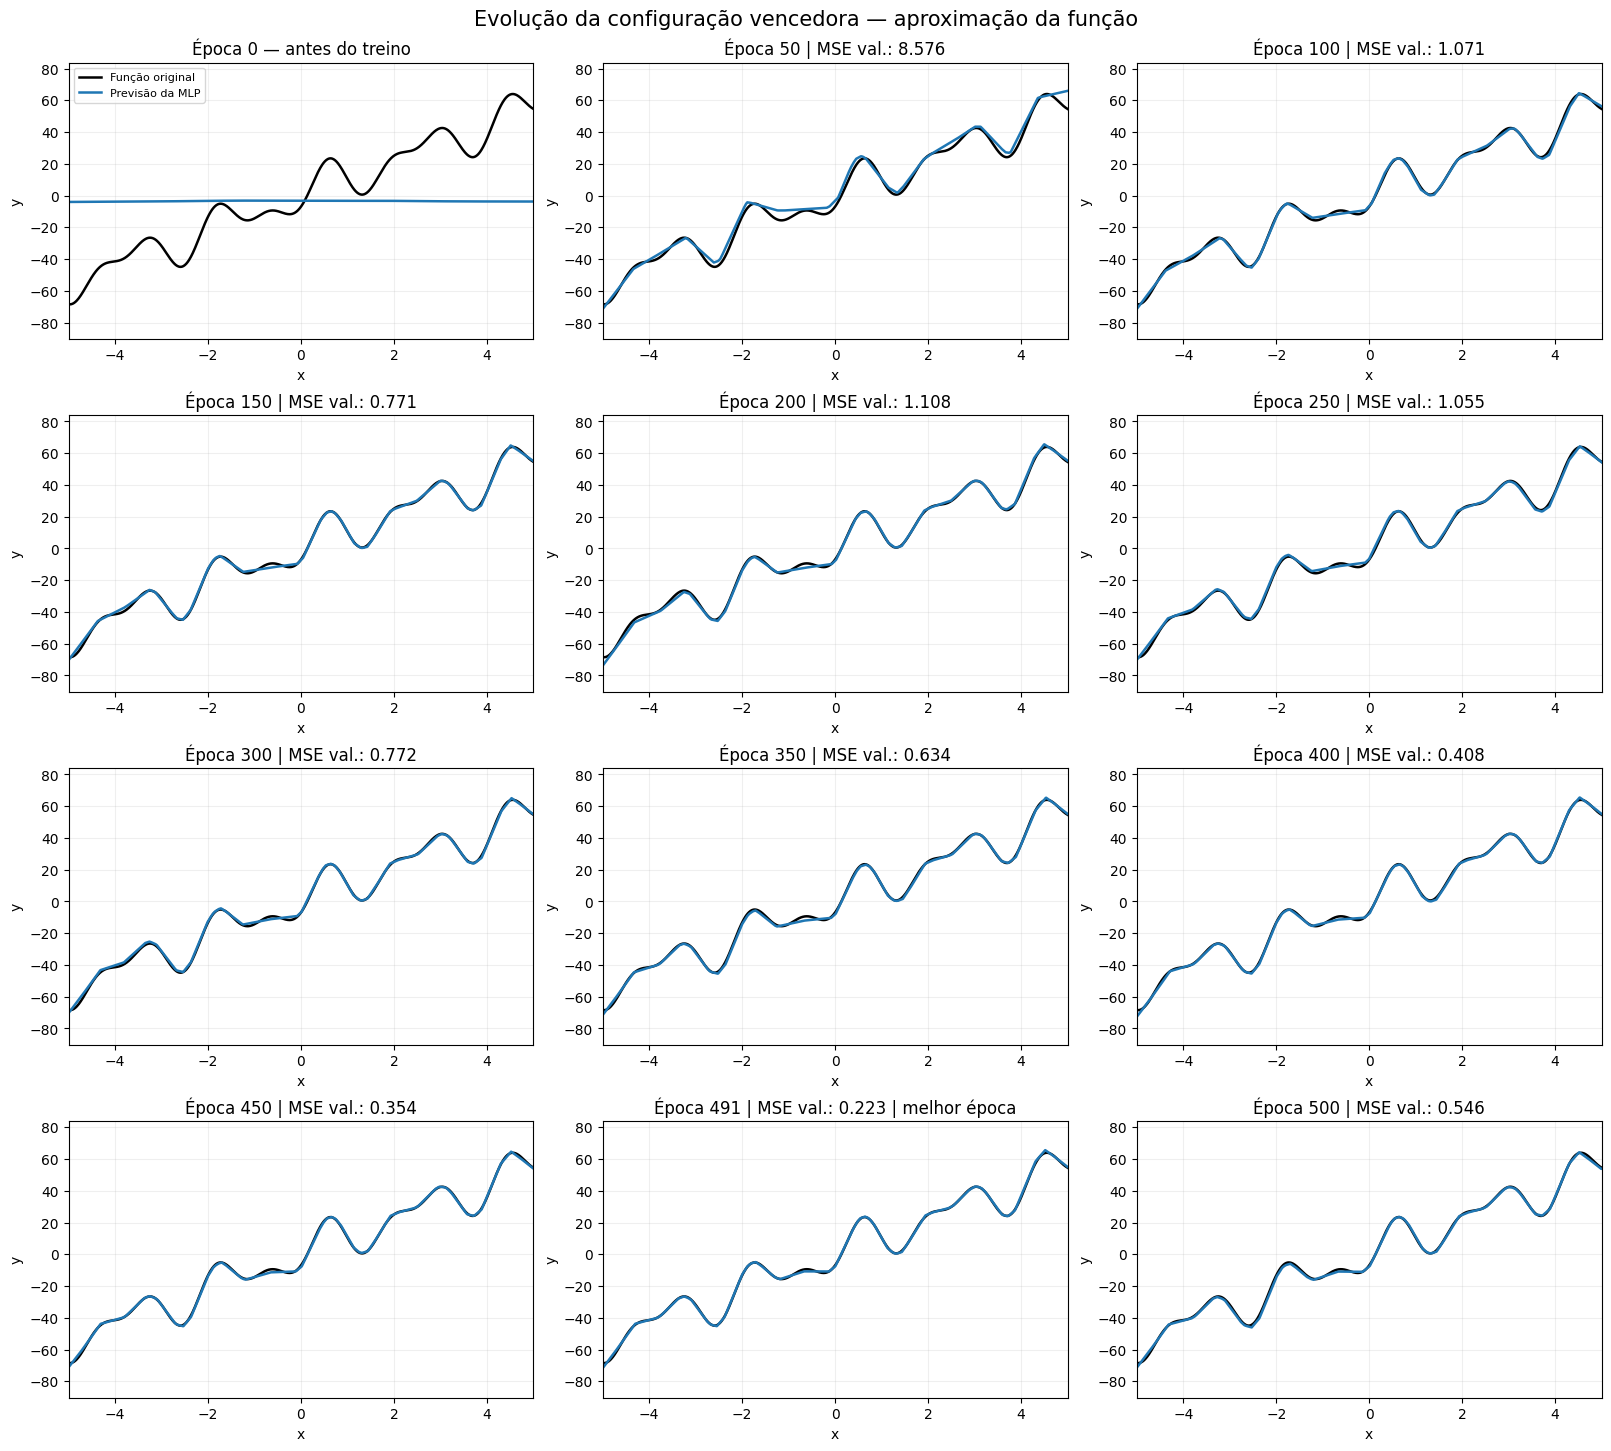

GIF, imagens individuais e painel salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\regression\combinacoes_20260917_174933_692138\evolucao_modelo_final_20260917_180154_220987


In [40]:
# Mostra apenas o painel estático; o GIF é salvo para abrir depois.
caminho_gif_final = visualizar_evolucao(
    registro_evolucao_final, intervalo_fotos=50, intervalo_gif=5, fps=8,
    nome_gif="evolucao_modelo_final.gif",
)